In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
import palantir

In [3]:
os.chdir("../../")

# read data

In [4]:
meahr_raw = sc.read_h5ad("data/meahr/David_cb.h5ad")
meahr_raw.obs_names_make_unique()
meahr_raw.layers['Counts'] = meahr_raw.X.copy()
meahr_raw.obsm['diff component'] = meahr_raw.obsm['X_dc'][:,:2]

OSError: Unable to open file (unable to open file: name = 'data/meahr/David_cb.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
meahr_raw

In [41]:
meahr_raw.obs.pseudodynamics_branching_region

obs_names
GGCATCGGTTAT.E17_5_WholeThy_rep2    nonbranching
TTTACTTTAGAG.E17_5_WholeThy_rep2    nonbranching
GTGCCGGGACAT.E17_5_WholeThy_rep2    nonbranching
ATTGTCTATATA.E17_5_WholeThy_rep2       branching
ACTCAAAAATTC.E17_5_WholeThy_rep2       branching
                                        ...     
AAAGTCTGAAAT.P0_WholeThy_rep1          branching
TGGGTGATGTGT.P0_WholeThy_rep1       nonbranching
CGCCTATGGGCT.P0_WholeThy_rep1       nonbranching
GTCACAGCTGAN.P0_WholeThy_rep1          branching
TCTGAACACCAC.P0_WholeThy_rep1       nonbranching
Name: pseudodynamics_branching_region, Length: 10890, dtype: category
Categories (2, object): ['branching', 'nonbranching']

In [42]:
meahr_raw.obs.pseudodynamics_branch_class

obs_names
GGCATCGGTTAT.E17_5_WholeThy_rep2    TC
TTTACTTTAGAG.E17_5_WholeThy_rep2    TC
GTGCCGGGACAT.E17_5_WholeThy_rep2    TC
ATTGTCTATATA.E17_5_WholeThy_rep2    TC
ACTCAAAAATTC.E17_5_WholeThy_rep2    TC
                                    ..
AAAGTCTGAAAT.P0_WholeThy_rep1       TC
TGGGTGATGTGT.P0_WholeThy_rep1       TC
CGCCTATGGGCT.P0_WholeThy_rep1       TC
GTCACAGCTGAN.P0_WholeThy_rep1       TC
TCTGAACACCAC.P0_WholeThy_rep1       TC
Name: pseudodynamics_branch_class, Length: 10890, dtype: category
Categories (3, object): ['NK', 'TC', 'progenitor']

In [131]:
# root cell is picked by the minimal pseudotime
root_idx = meahr_raw.obs['pseudotime'].argmin()
meahr_raw.uns['iroot'] = root_idx

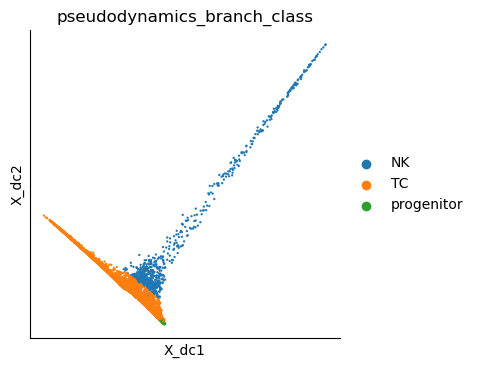

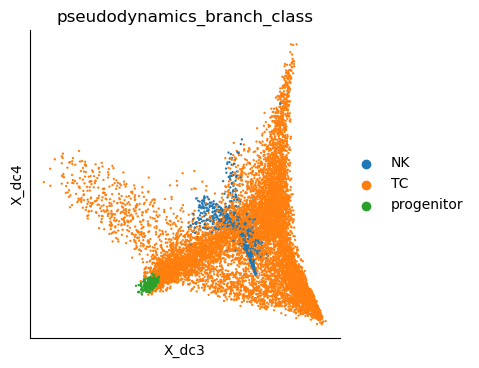

In [135]:
sc.pl.embedding(meahr_raw, components='1,2', basis='X_dc', color='pseudodynamics_branch_class')
sc.pl.embedding(meahr_raw, components='3,4', basis='X_dc', color='pseudodynamics_branch_class')

# run preprocessing

In [63]:
meahr_raw.var_names.str.startswith("MT-").sum(), meahr_raw.var_names.str.startswith(("RPS", "RPL")).sum()

(0, 0)

In [65]:
# Normalizing to median total counts
meahr = meahr_raw.copy()
meahr.raw = sc.pp.log1p(meahr, copy=True)
sc.pp.recipe_weinreb17(meahr, log=True, random_state=0) # Do log-transform.

sc.pp.neighbors(meahr, n_neighbors=100, knn=True, method='umap', n_pcs=50, random_state=0)
sc.tl.diffmap(meahr)
sc.tl.umap(meahr)
# sc.pp.highly_variable_genes(meahr, n_top_genes=2000, batch_key="batch_y")

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [143]:
meahr_raw.raw = sc.pp.log1p(meahr_raw, copy=True)
sc.pp.recipe_weinreb17(meahr_raw, log=False,  random_state=0) # Do log-transform.
sc.pp.neighbors(meahr_raw, n_neighbors=15, knn=True, method='umap', n_pcs=50, random_state=0)
sc.tl.diffmap(meahr_raw)
sc.tl.umap(meahr_raw)
sc.tl.leiden(meahr_raw, resolution=2.5, flavor='leidenalg', random_state=0)
sc.tl.paga(meahr_raw)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


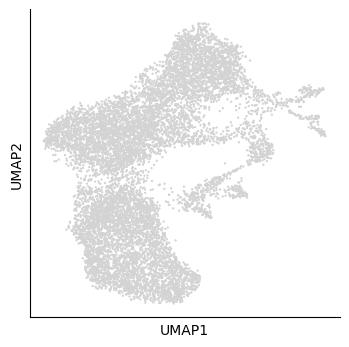

In [44]:
# sc.tl.umap(meahr_raw)
sc.pl.umap(meahr_raw)

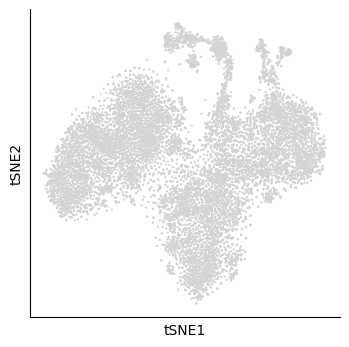

In [51]:
sc.tl.tsne(meahr_raw)
sc.pl.tsne(meahr_raw)

In [156]:
sc.pp.neighbors(meahr_raw, n_neighbors=100, knn=False, method='gauss', n_pcs=50, random_state=0)
sc.tl.diffmap(meahr_raw)
sc.tl.dpt(meahr_raw, n_dcs=15)

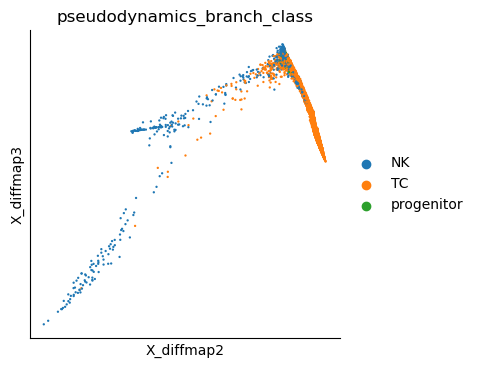

In [154]:
sc.pl.embedding(meahr_raw, components='2,3', basis='X_diffmap', color='pseudodynamics_branch_class')

In [68]:
sc.tl.leiden(meahr, resolution=2.5, flavor='leidenalg', random_state=0)
sc.tl.paga(meahr)

/tmp/ipykernel_1673089/3714475228.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(meahr, resolution=2.5, flavor='leidenalg', random_state=0)


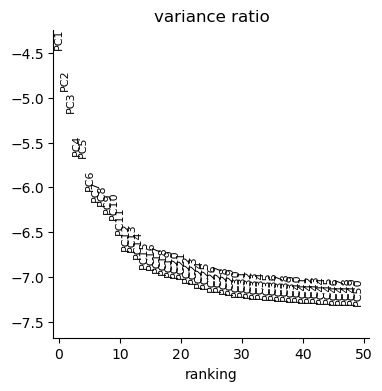

In [71]:
sc.tl.pca(meahr)
sc.pl.pca_variance_ratio(meahr, n_pcs=50, log=True)
sc.pp.neighbors(meahr)

In [72]:
meahr.obs['Time_x'] = meahr.obs_names.str.extract('\w{10,18}\.([E|P]\d{1,2}(_\d)?)')[0].values
meahr.obs['Time_y'] = meahr.obs['batch_to_match'].str.extract('([E|P]\d{1,2}(_\d)?)')[0].values

In [146]:
np.mean(meahr.obs['Time_x'] == meahr.obs['Time_y'])

0.9985046728971962

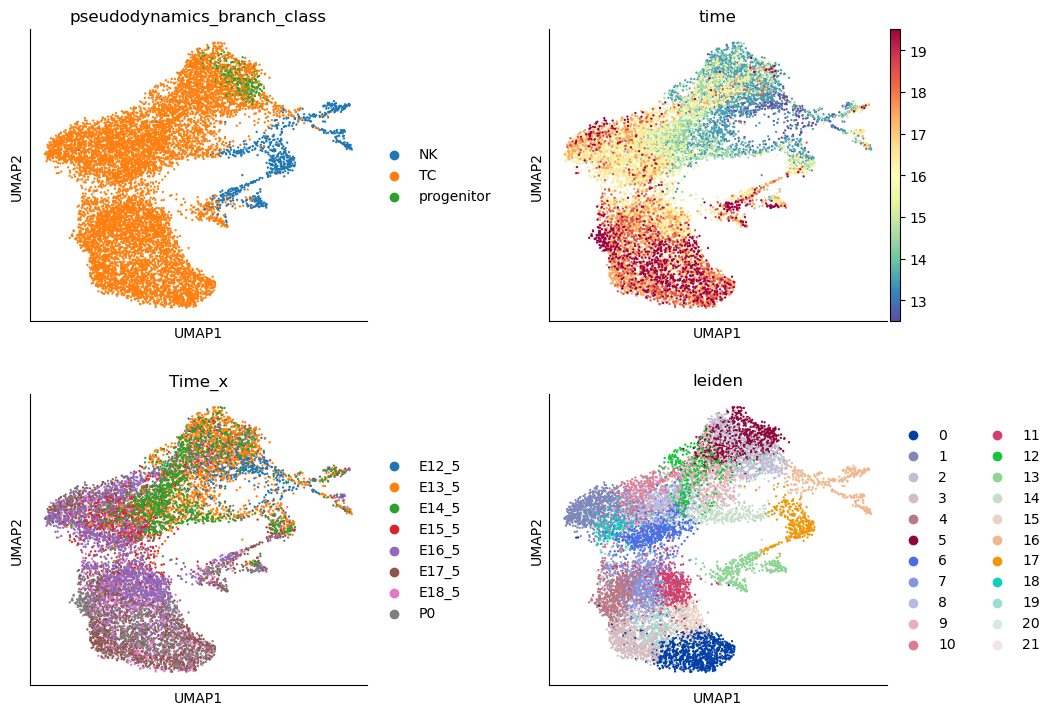

In [81]:
# 
sc.pl.umap(meahr, color=['pseudodynamics_branch_class', 'time', 'Time_x', 'leiden'], ncols=2, wspace=0.4)

In [100]:
weird_TC = meahr.obs.query("`pseudodynamics_branch_class` == 'TC' & `leiden` == '13'").index

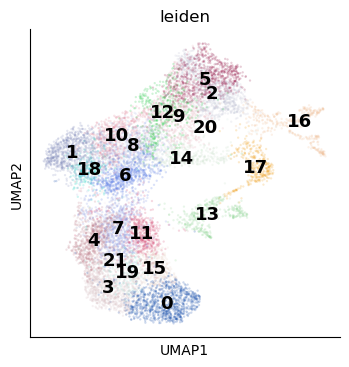

In [65]:
# 
sc.pl.umap(meahr, color=['leiden'], legend_loc='on data', alpha=0.2, legend_fontsize=13)

# find myloid cells

In [37]:
# Leukocyte markers:
leuk_markers = ['Ptprc']
# T-cell markers: 
# CD25=Il2ra
tc_markers = ['Flt3','Cd44', 'Il2ra','Ptcra','Rag1','Rag2','Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Notch1', 'Bcl11b']
cd3_markers = ['Cd3d', 'Cd3e', 'Cd3g']
# alpha-beta T-cell makers (double positives):
ab_tc_markers = ['Id3', 'Rorc','Cd4', 'Cd8a', 'Cd8b1']
# gamma-delta T-cell markers:
yd_tc_markers = ['Ifng', 'Il17a']
# TCR (from separate alignment)
tcr_markers = ['TCRa', 'TCRb', 'TCRy', 'TCRd']
# Natural-killer cell markers
nk_markers = ['Il2rb', 'Ncr1', 'Klrd1', 'Klrb1b', 'Klrb1f']

# Hematopoietic stem cell markers:
sc_markers = ['Cd34']
# Myeloid cell markers: 
# Cd11c=Itgax, CD11b=Itgam, Cd16=Fcgr3
myeloid_markers = ['Itgax', 'Itgam', 'Fcgr3', "Mpo", "Cd14", "Elane", "S100a8"]
# Macrophage/monocyte markers:
# CD11b=Itgam, Ly-71=Adgre1, Lyz2: lysozyme
mp_markers = ['Adgre1', 'Lyz2']
# Dendritic cell markers
# Cd74=Cd74, CD11b=Itgam, CD13=Anpep, CD33=Cd33, CD80h=Cd80, CD83=Cd83, CD86=Cd86
dc_markers = ['Cd74', 'Anpep' , 'Cd33', 'Cd80', 'Cd83', 'Cd86'] 
# B-cell markers
bc_markers = ['Cd19']

leuk_markers = np.array([x for x in leuk_markers if x in meahr.var_names])

tc_markers = np.array([x for x in tc_markers if x in meahr.var_names])
cd3_markers = np.array([x for x in cd3_markers if x in meahr.var_names])
ab_tc_markers = np.array([x for x in ab_tc_markers if x in meahr.var_names])
yd_tc_markers = np.array([x for x in yd_tc_markers if x in meahr.var_names])
nk_markers = np.array([x for x in nk_markers if x in meahr.var_names])

sc_markers = np.array([x for x in sc_markers if x in meahr.var_names])
myeloid_markers = np.array([x for x in myeloid_markers if x in meahr.var_names])
mp_markers = np.array([x for x in mp_markers if x in meahr.var_names])
dc_markers = np.array([x for x in dc_markers if x in meahr.var_names])
bc_markers = np.array([x for x in bc_markers if x in meahr.var_names])

In [38]:
myeloid_markers

array(['Fcgr3', 'Mpo'], dtype='<U5')

In [30]:
np.concatenate([tc_markers,cd3_markers,yd_tc_markers])

array(['Cd44'], dtype='<U32')

In [31]:
import matplotlib.pyplot as plt

In [ ]:
sc.pl.umap(meahr, color=nk_markers)

In [61]:
marker_dict = {
"leuk_markers":leuk_markers,
"tc_markers":tc_markers,
"cd3_markers":cd3_markers,
"ab_tc_markers":ab_tc_markers,
"yd_tc_markers":yd_tc_markers,
"nk_markers":nk_markers,
"sc_markers":sc_markers,
"myeloid_markers":myeloid_markers,
"mp_markers":mp_markers,
"dc_markers":dc_markers,
"bc_markers":bc_markers}

In [ ]:
with plt.rc_context({'figure.figsize':(2,2), 'figure.dpi':200}):
    for marker, genes in marker_dict.items():
        if len(genes)==0:
            continue
        fig = sc.pl.umap(meahr_raw, color=genes, return_fig=True, frameon=False)
        fig.suptitle(marker+"\n\n", y=1.2)

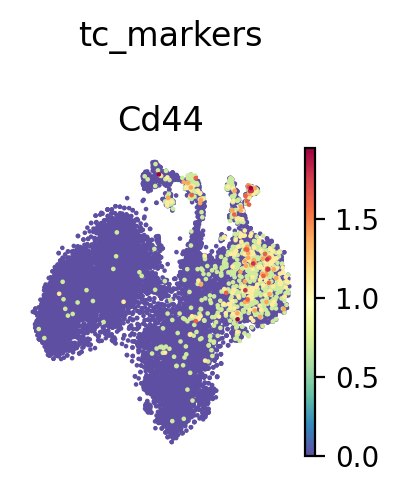

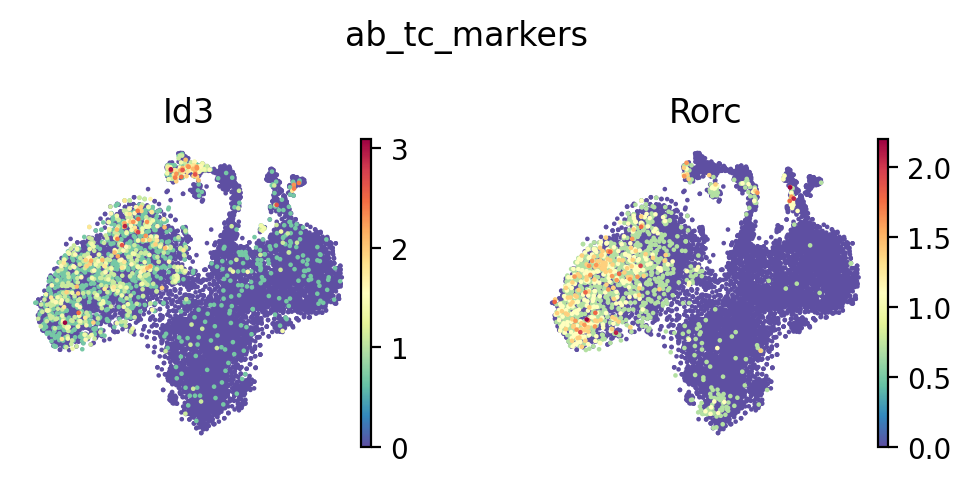

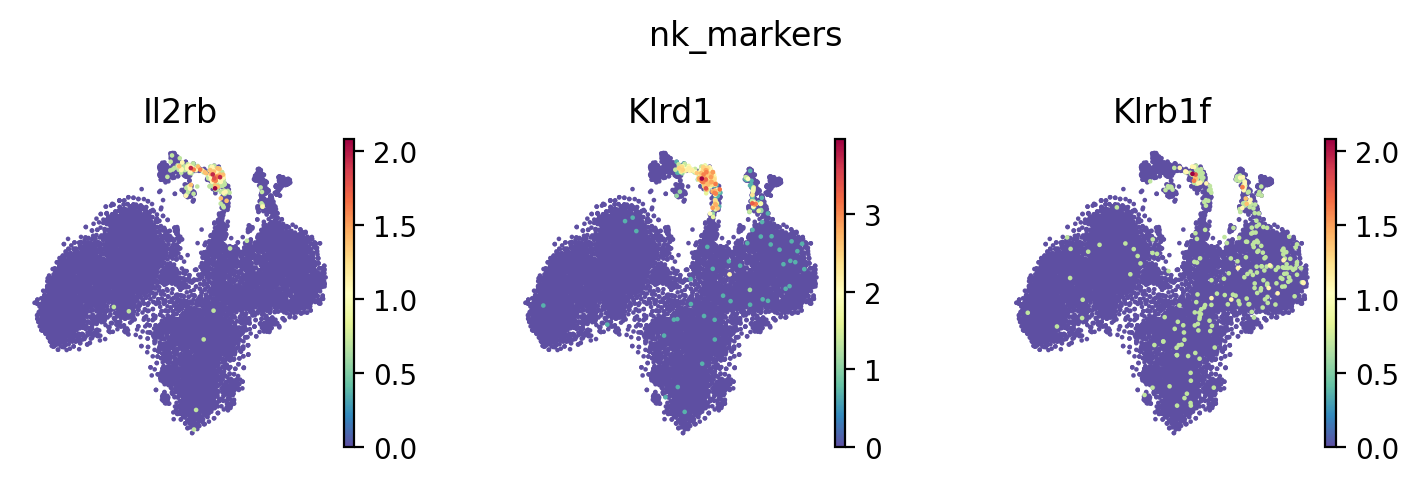

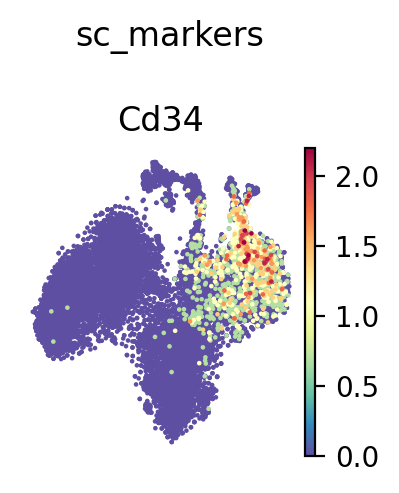

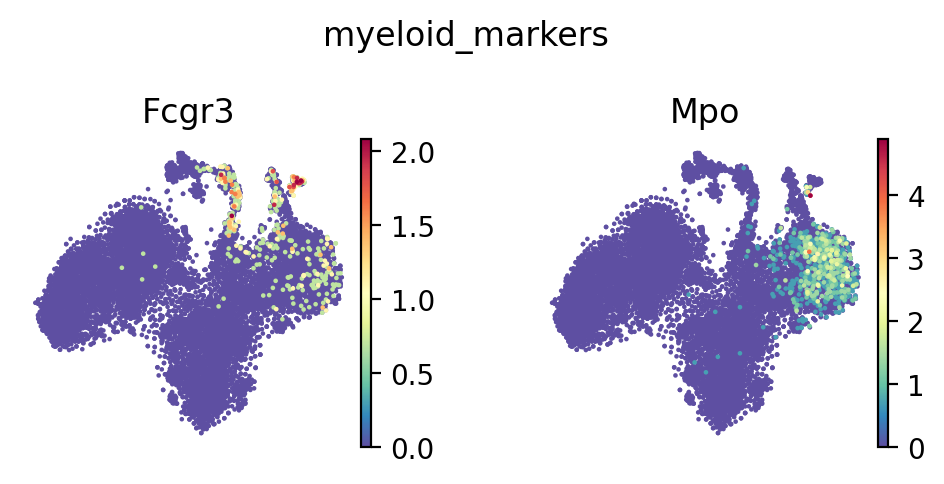

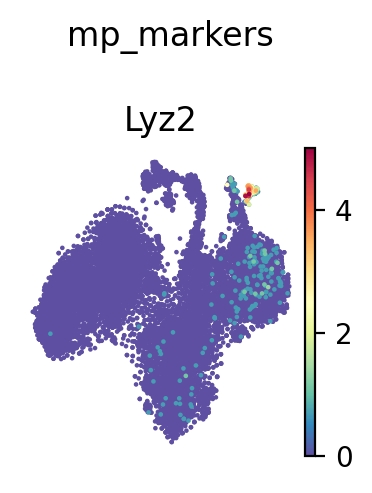

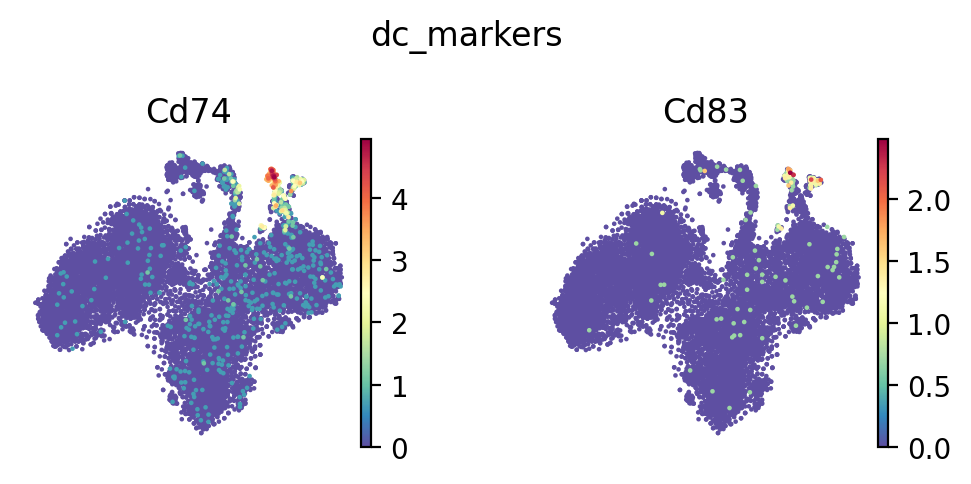

In [63]:
with plt.rc_context({'figure.figsize':(2,2), 'figure.dpi':200}):
    for marker, genes in marker_dict.items():
        if len(genes)==0:
            continue
        fig = sc.pl.tsne(meahr_raw, color=genes, return_fig=True, frameon=False)
        fig.suptitle(marker+"\n\n", y=1.2)

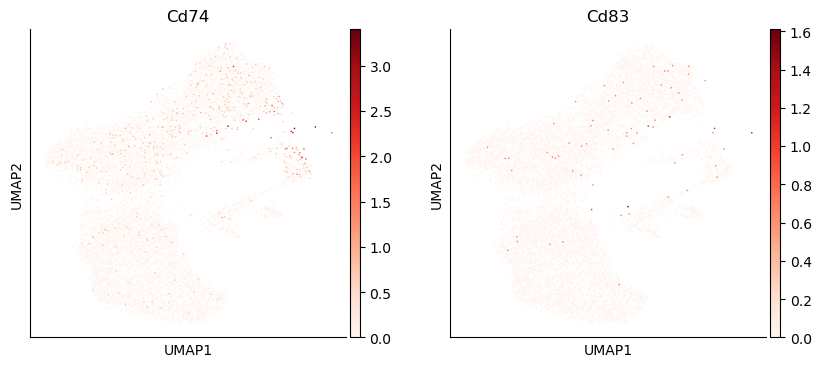

In [33]:
sc.pl.umap(meahr, color=dc_markers, use_raw=True, size=5, color_map='Reds')

# run diffmap and pseudotime 

In [ ]:
sc.pp.neighbors(meahr, n_neighbors=100, knn=False, method='gauss', n_pcs=50, random_state=0)
sc.tl.diffmap(meahr)
sc.tl.dpt(meahr, n_dcs=15)

In [77]:
sc.pp.neighbors(meahr, n_neighbors=100, knn=False, method='gauss', n_pcs=50, random_state=0)
sc.tl.diffmap(meahr)

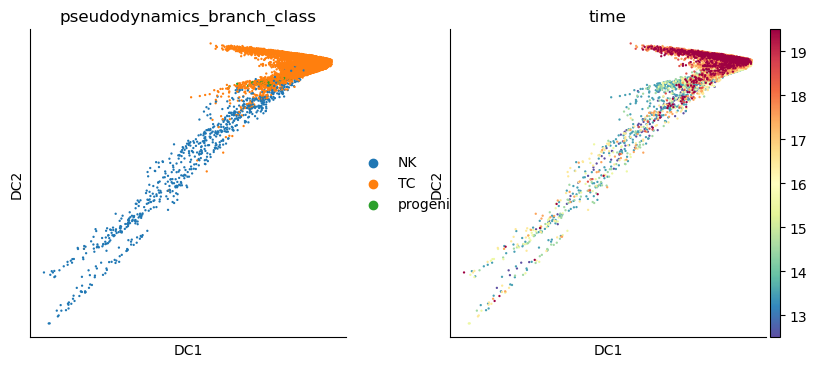

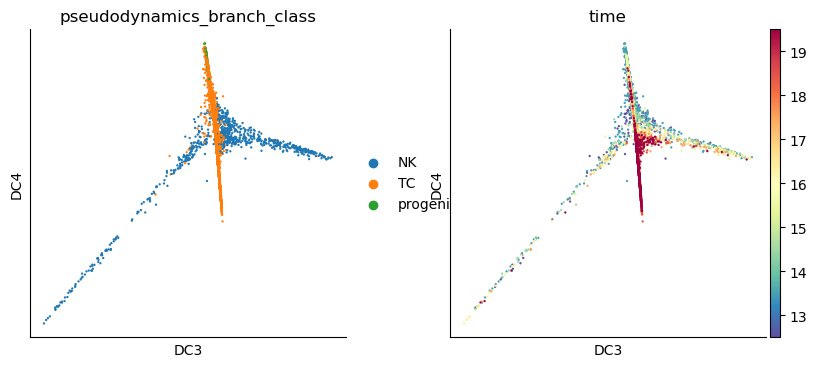

In [88]:
sc.pl.diffmap(meahr, components='1,2', color=['pseudodynamics_branch_class', 'time'])

sc.pl.diffmap(meahr, components='3,4', color=['pseudodynamics_branch_class', 'time'])

In [83]:
meahr.write_h5ad("data/meahr/David_cb.h5ad")

# run palantir

In [116]:
meahr = sc.read_h5ad("data/meahr/David_cb.h5ad")

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [117]:
meahr.obs_names_make_unique()
weird_TC = list(meahr.obs.query("`pseudodynamics_branch_class` == 'TC' & `leiden` == '14'").index)
weird_TC += list(meahr.obs.query("`leiden` == '16'").index)
cell_to_stay = [cb for cb in meahr.obs_names if cb not in weird_TC]
meahr = meahr[cell_to_stay]

In [118]:
meahr.obsm['X_tsne']= meahr_raw[meahr.obs_names].obsm['X_tsne'].copy()

/tmp/ipykernel_421313/4273954840.py:1: ImplicitModificationWarning: Setting element `.obsm['X_tsne']` of view, initializing view as actual.
  meahr.obsm['X_tsne']= meahr_raw[meahr.obs_names].obsm['X_tsne'].copy()


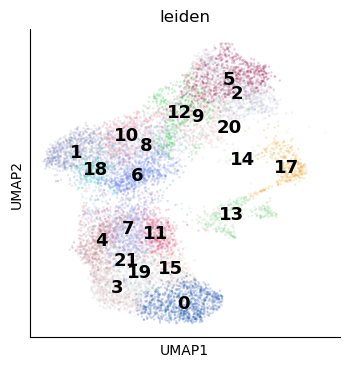

In [16]:
sc.pl.umap(meahr, color=['leiden'], legend_loc='on data', alpha=0.2, legend_fontsize=13)

In [17]:
meahr.shape[0] , len(np.unique(meahr.obs_names))

(10250, 10250)

In [64]:
meahr.obs_names_make_unique()
meahr.shape[0] , len(np.unique(meahr.obs_names))

(10250, 10250)

## recompute PC and neighbor

In [133]:
# sc.pp.recipe_weinreb17(meahr, log=False, random_state=0) # Do log-transform.
sc.pp.neighbors(meahr, n_neighbors=100, knn=True, n_pcs=50, random_state=0)

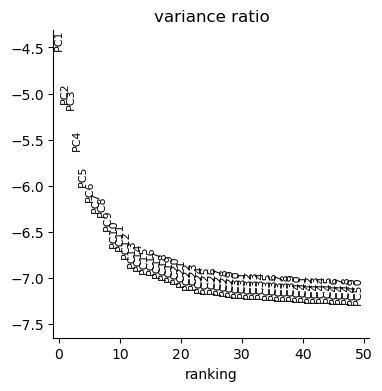

In [65]:
# sc.tl.pca(meahr)
# sc.pl.pca_variance_ratio(meahr, n_pcs=50, log=True)
# sc.pp.neighbors(meahr)

In [197]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(meahr)
ms_data = palantir.utils.determine_multiscale_space(meahr)
imputed_X = palantir.utils.run_magic_imputation(meahr)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


In [135]:
# coo_conn = coo_matrix(meahr.obsp["connectivities"])
# meahr.obsp["connectivities_dense"] = meahr.obsp["connectivities"].copy()
# meahr.obsp["connectivities"] =coo_conn

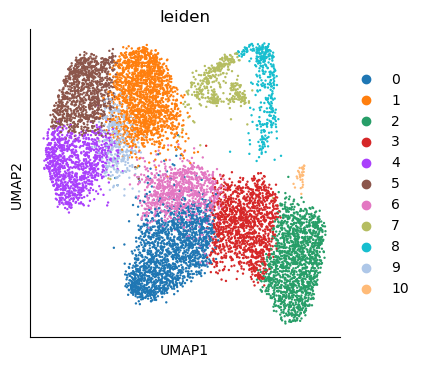

In [162]:
sc.tl.leiden(meahr, resolution=1.2)
sc.pl.umap(meahr, color='leiden')

In [184]:
sc.tl.paga(meahr, groups='leiden')

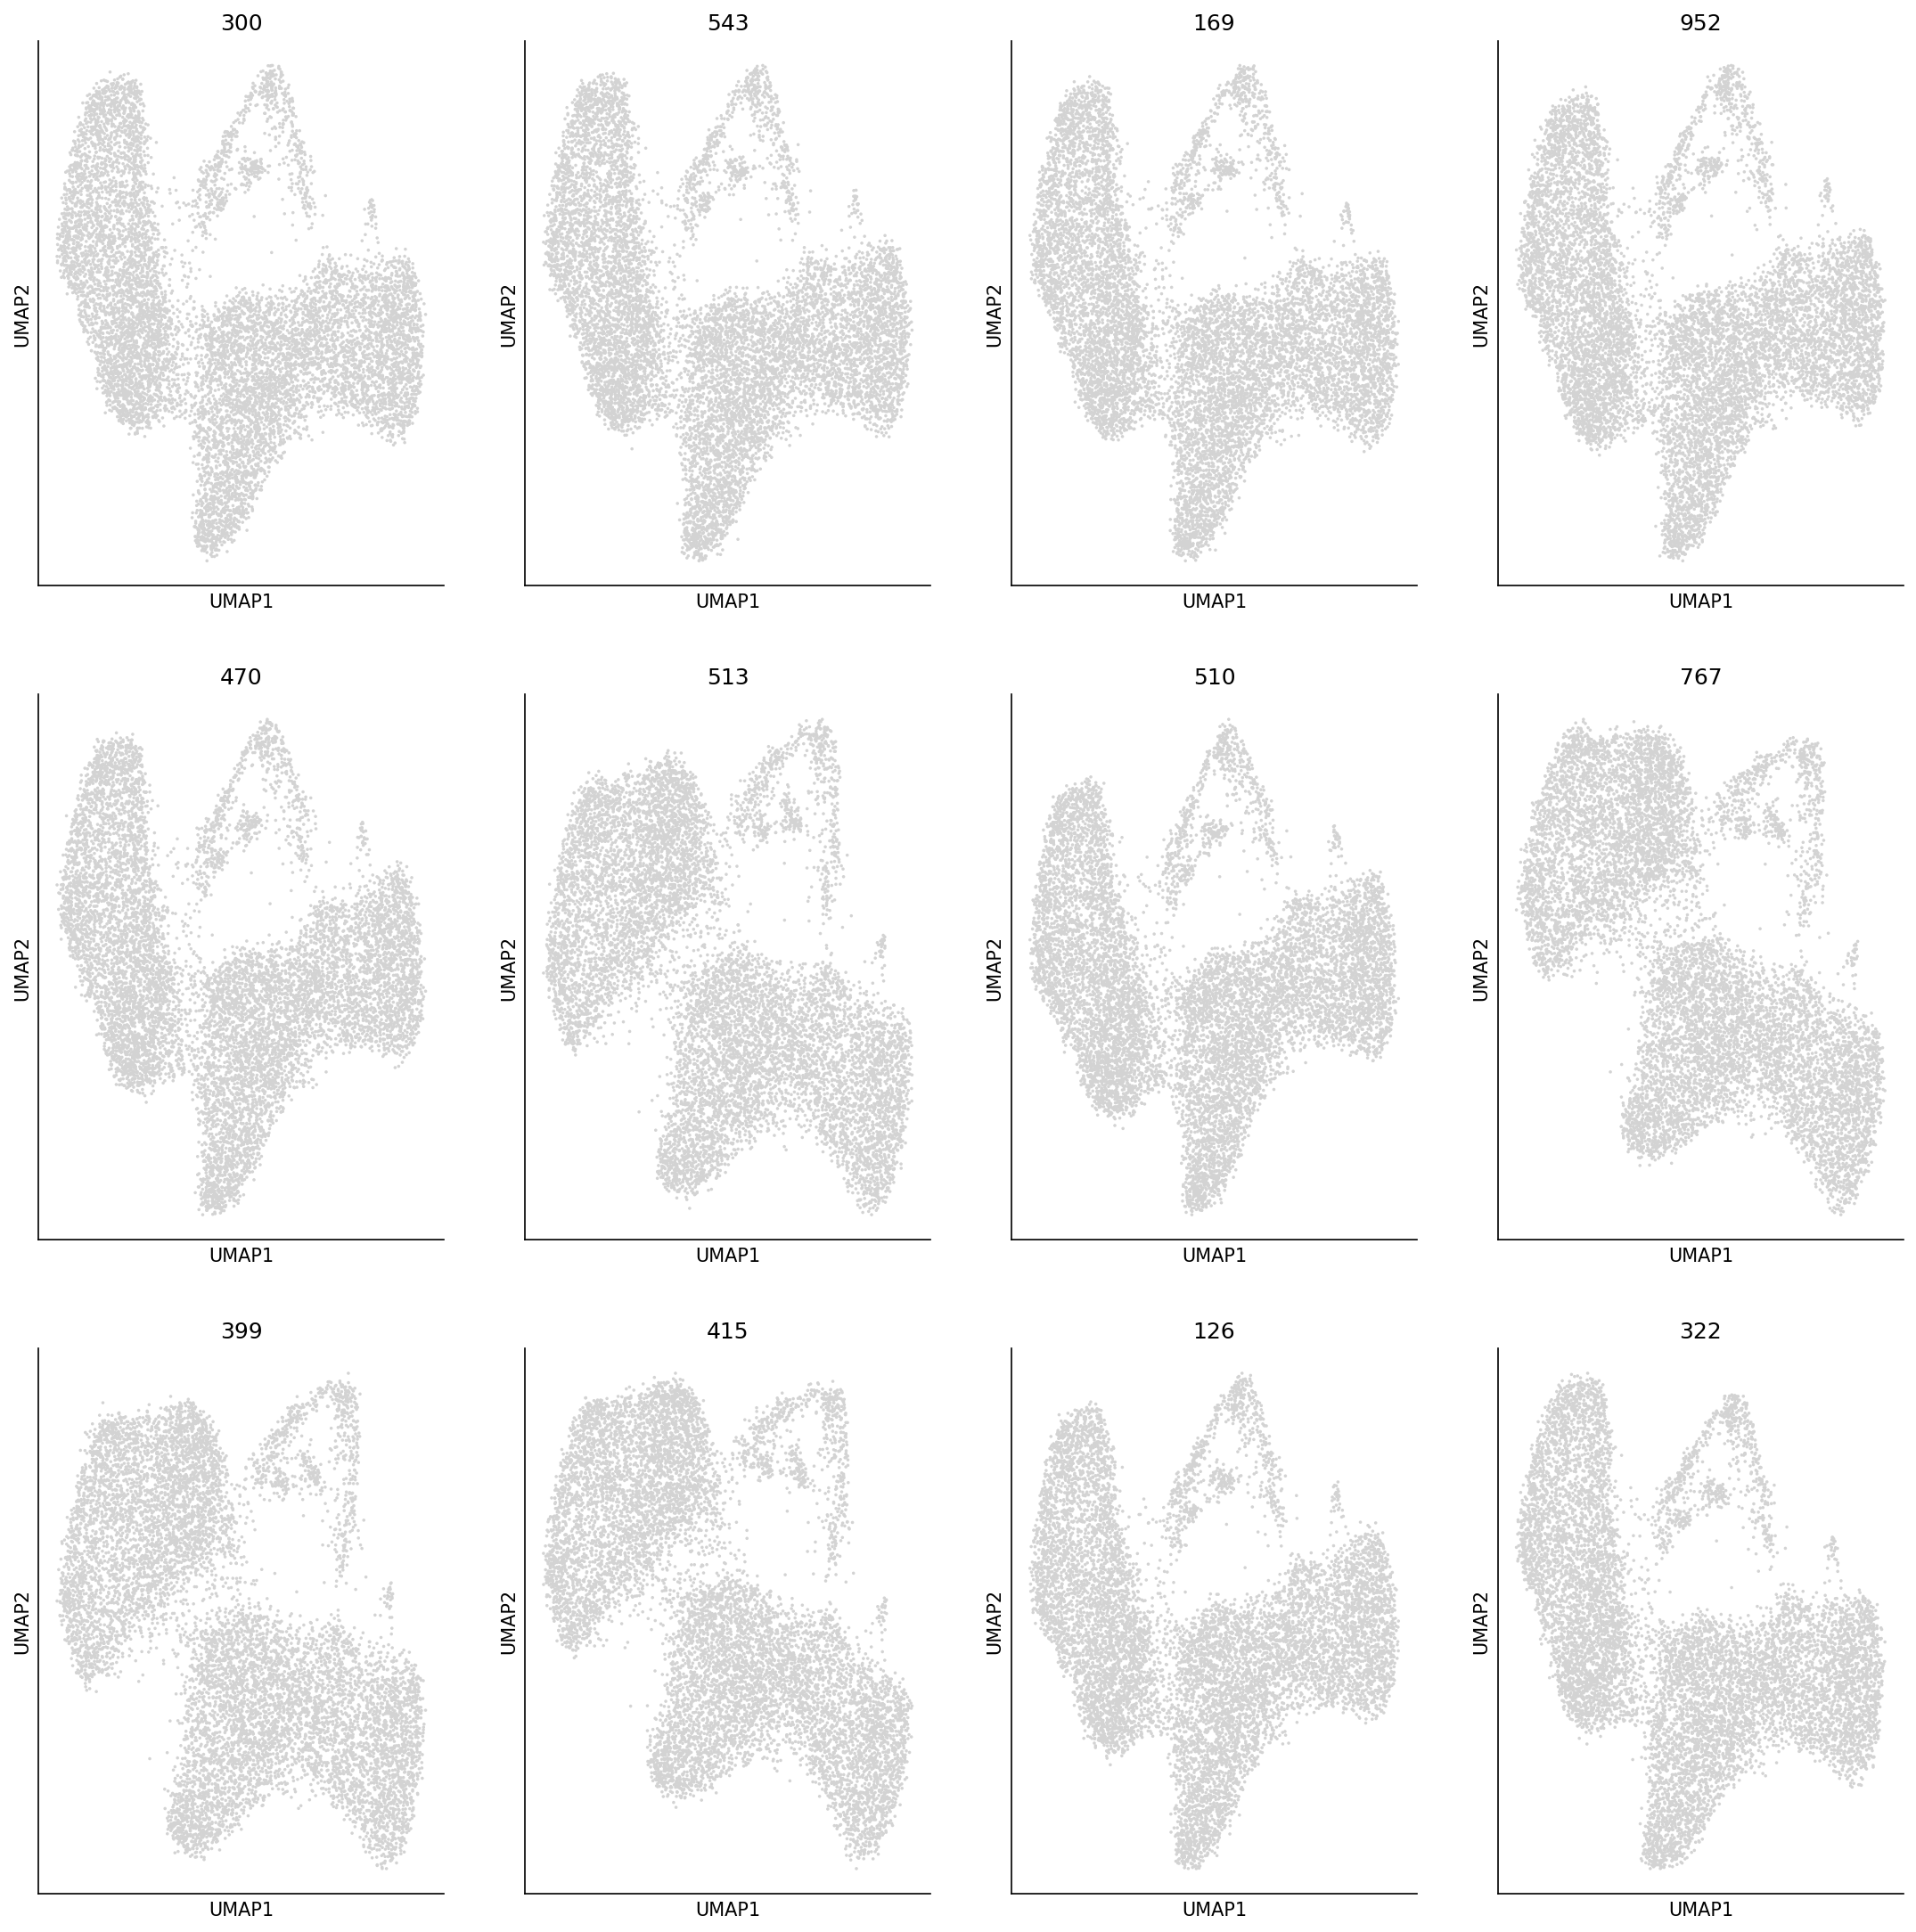

In [201]:
fig ,axs = plt.subplots(3,4, figsize=(18,18), dpi=150)
axs= axs.flatten()
for i in range(12):
    seed = np.random.randint(0,1000)
    sc.tl.umap(meahr, random_state=seed)
    sc.pl.umap(meahr, title=str(seed), show=False, ax=axs[i])

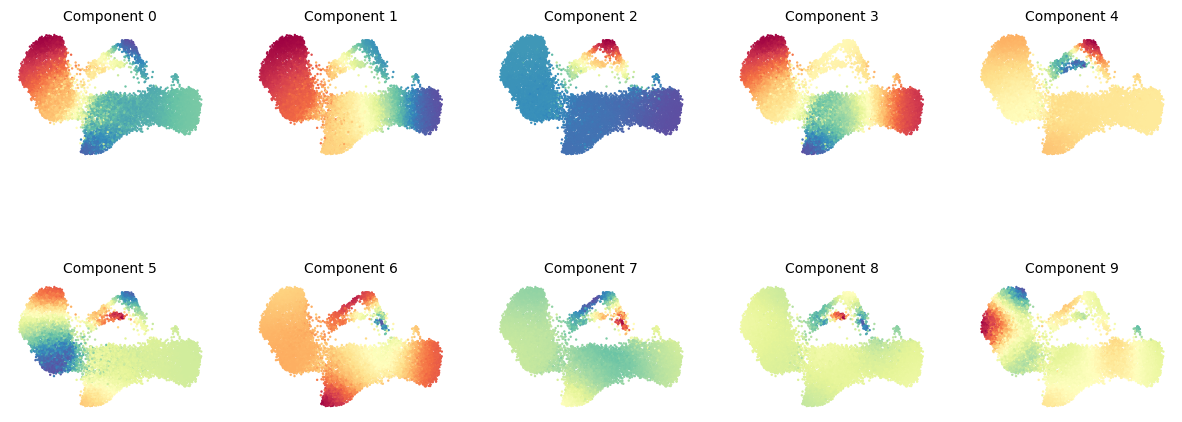

In [202]:
palantir.plot.plot_diffusion_components(meahr);

In [186]:
meahr.obs.query('`Time_x` == "E12_5"').pseudotime.argmin()

319

AGCGGTCAACAN.P0_WholeThy_rep1
TGGTTGTTTCGC.P0_WholeThy_rep2
ACCTTAGGCGCC.E12_5_WholeThy_venus_rep3


(<Figure size 400x400 with 1 Axes>, <Axes: >)

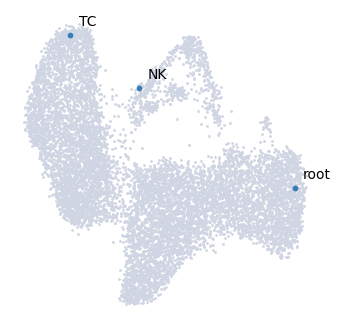

In [203]:
# terminal mk
nk_cells =  meahr.obs.query('`pseudodynamics_branch_class` == "NK" & `Time_x` == "P0" & `leiden` == "7"')
nk_terminal_idx = nk_cells.pseudotime.argmax()
nk_terminal_cb = nk_cells.iloc[nk_terminal_idx].name
print(nk_terminal_cb)

# terminal ery
tc_cells =  meahr.obs.query('`pseudodynamics_branch_class` == "TC" & `Time_x` == "P0"')
tc_terminal_idx = tc_cells.pseudotime.argmax()
tc_terminal_cb = tc_cells.iloc[tc_terminal_idx].name
print(tc_terminal_cb)

# root
root_idx = meahr.obs.query('`Time_x` == "E12_5"').pseudotime.argmin()
root_cb = meahr.obs.query('`Time_x` == "E12_5"').iloc[root_idx].name
print(root_cb)
all_states = pd.Series(
    ["NK", "TC", "root"],
    index=[nk_terminal_cb, tc_terminal_cb, root_cb],
)

terminal_states = pd.Series(
    ["NK", "TC"],
    index=[nk_terminal_cb, tc_terminal_cb],
)
palantir.plot.highlight_cells_on_umap(meahr, all_states)

In [204]:
start_cell = root_cb
pr_res = palantir.core.run_palantir(
    meahr, start_cell, knn=30, num_waypoints=500, terminal_states=terminal_states
)

Sampling and flocking waypoints...


Time for determining waypoints: 0.004911088943481445 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Time for shortest paths: 1.882916796207428 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


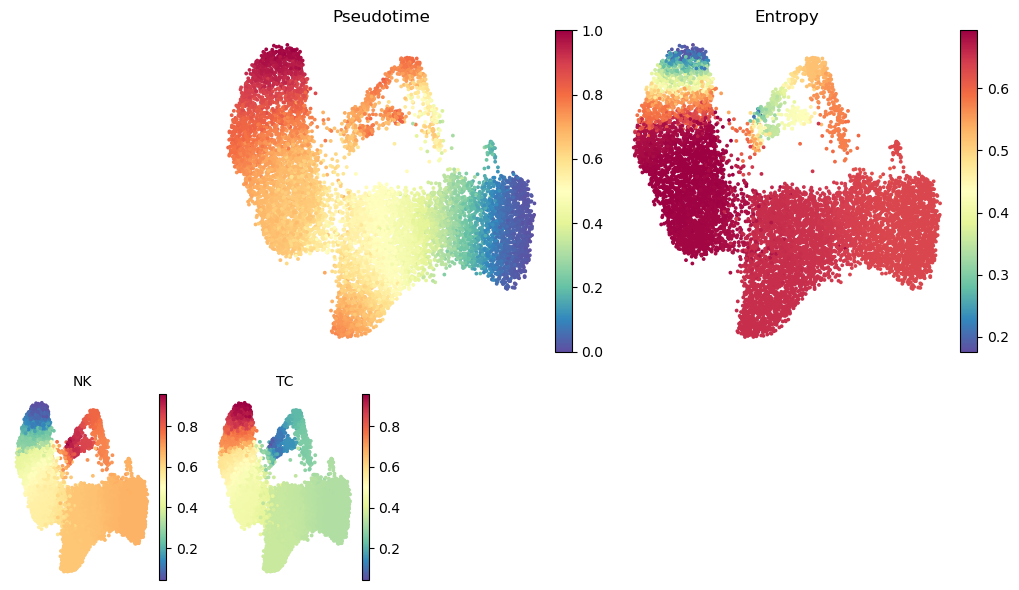

In [205]:
palantir.plot.plot_palantir_results(meahr, s=3);

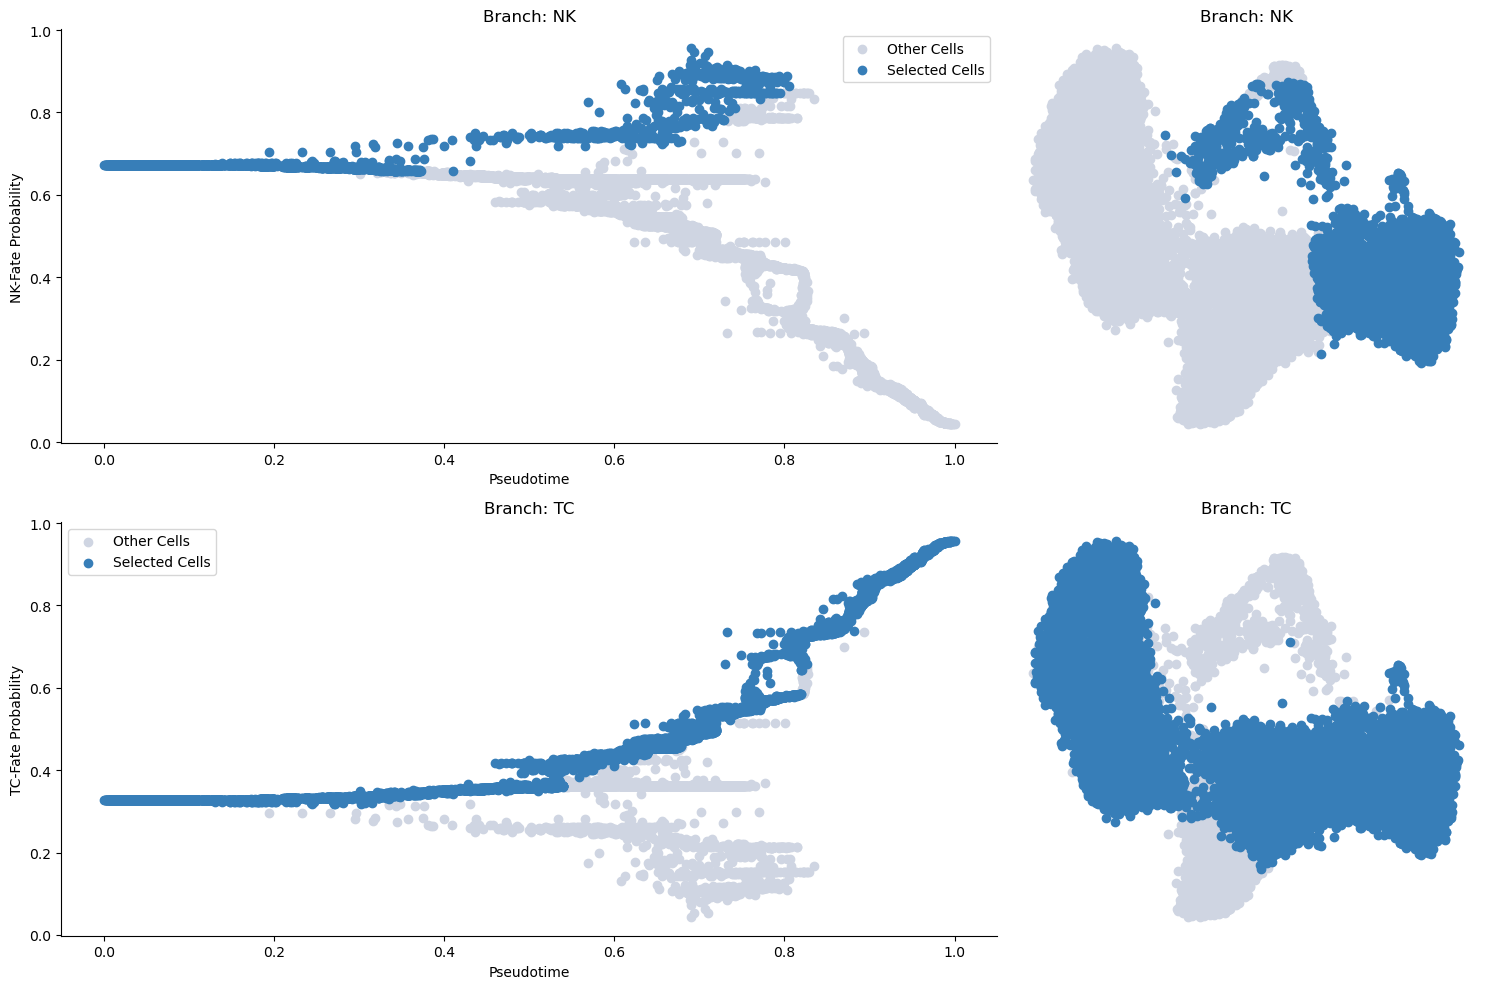

In [206]:
masks = palantir.presults.select_branch_cells(meahr, q=.02, eps=.02)
palantir.plot.plot_branch_selection(meahr);

[2024-09-20 21:56:10,696] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (2,931) and rank = 1.0.
[2024-09-20 21:56:10,697] [INFO    ] Using covariance function Matern52(ls=0.88929443359375).
[2024-09-20 21:56:10,726] [INFO    ] Computing 50 landmarks with k-means clustering.


[2024-09-20 21:56:11,389] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (8,193) and rank = 1.0.
[2024-09-20 21:56:11,390] [INFO    ] Using covariance function Matern52(ls=0.88929443359375).
[2024-09-20 21:56:11,414] [INFO    ] Computing 50 landmarks with k-means clustering.


<Axes: title={'center': 'Branch: TC'}>

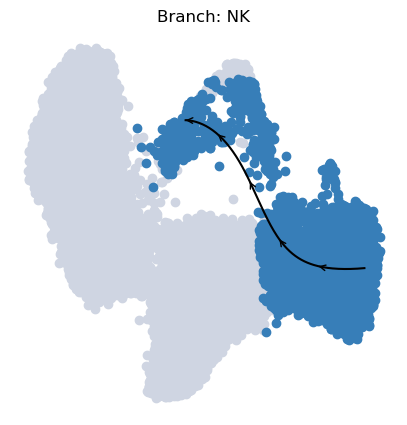

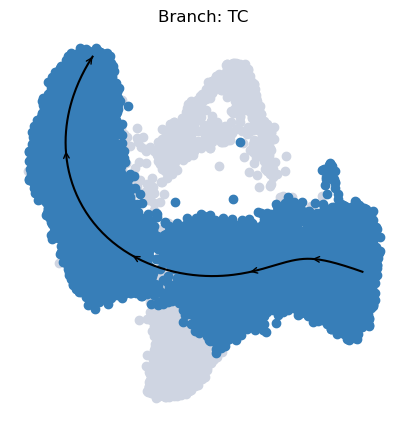

In [207]:
palantir.plot.plot_trajectory(meahr, "NK")
palantir.plot.plot_trajectory(meahr, "TC")

In [208]:
meahr.obsm['DM_EigenVectors_multiscaled'].min(axis=0), meahr.obsm['DM_EigenVectors_multiscaled'].max(axis=0)

(array([-1.275631  , -0.3889264 , -0.5756087 , -0.85572916, -0.26422444,
        -0.5781341 , -0.32355863], dtype=float32),
 array([0.96626   , 2.909268  , 0.43431166, 0.62747914, 0.4439517 ,
        0.2801483 , 0.7110495 ], dtype=float32))

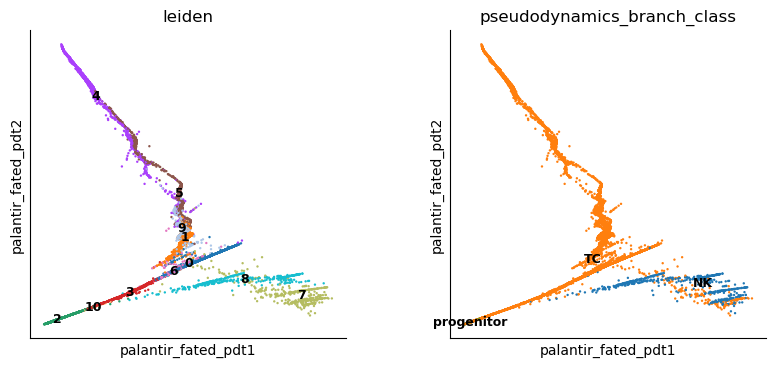

In [216]:
meahr.obsm['palantir_fated_pdt'] = np.multiply(meahr.obsm['palantir_fate_probabilities'].values , meahr.obs['palantir_pseudotime'].values.reshape(-1,1))
sc.pl.embedding(meahr, basis='palantir_fated_pdt', color=['leiden','pseudodynamics_branch_class'], legend_loc='on data', legend_fontsize=9)

In [217]:
meahr.obs.query("`leiden` == '7' & `pseudodynamics_branch_class` == 'NK'")

,barcodes,batch_x,pseudodynamics_branching_region,pseudodynamics_branch_class,dpt_adjusted_groups,time,batch_y,pseudotime,cell,dc1,...,batch_to_match,leiden,Time_x,Time_y,dpt_pseudotime,dpt_groups,dpt_order,dpt_order_indices,palantir_pseudotime,palantir_entropy
obs_names,,,,,,,,,,,,,,,,,,,,,
GTCTGCTAGGGA.E17_5_WholeThy_rep2,GTCTGCTAGGGA,E17_5_WholeThy_rep2,branching,NK,intermediate,17.5,E17_5_WholeThy_rep2,0.228906,GTCTGCTAGGGA.E17_5_WholeThy_rep2,0.006839,...,E17_5_WholeThy_rep2,7,E17_5,E17_5,0.325378,0,7785,9848,0.693038,0.348675
ATCAGGATGTCA.E17_5_WholeThy_rep2,ATCAGGATGTCA,E17_5_WholeThy_rep2,branching,NK,intermediate,17.5,E17_5_WholeThy_rep2,0.212840,ATCAGGATGTCA.E17_5_WholeThy_rep2,0.004499,...,E17_5_WholeThy_rep2,7,E17_5,E17_5,0.407530,3,10744,9013,0.829245,0.427353
GAAGTGTGCCAG.E17_5_WholeThy_rep2,GAAGTGTGCCAG,E17_5_WholeThy_rep2,branching,NK,intermediate,17.5,E17_5_WholeThy_rep2,0.211102,GAAGTGTGCCAG.E17_5_WholeThy_rep2,0.001166,...,E17_5_WholeThy_rep2,7,E17_5,E17_5,0.348678,3,10676,8907,0.607847,0.386480
TAGCCATCGCGT.E17_5_WholeThy_rep2,TAGCCATCGCGT,E17_5_WholeThy_rep2,branching,NK,intermediate,17.5,E17_5_WholeThy_rep2,0.203372,TAGCCATCGCGT.E17_5_WholeThy_rep2,0.002741,...,E17_5_WholeThy_rep2,7,E17_5,E17_5,0.304376,0,6697,686,0.680986,0.412383
GACAAGCCATTG.E17_5_WholeThy_rep2,GACAAGCCATTG,E17_5_WholeThy_rep2,branching,NK,intermediate,17.5,E17_5_WholeThy_rep2,0.213665,GACAAGCCATTG.E17_5_WholeThy_rep2,0.003721,...,E17_5_WholeThy_rep2,7,E17_5,E17_5,0.319875,0,7585,10433,0.696197,0.345850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AATAAGCGATAG.P0_WholeThy_rep1,AATAAGCGATAG,P0_WholeThy_rep1,branching,NK,intermediate,19.5,P0_LeftLobe,0.245898,AATAAGCGATAG.P0_WholeThy_rep1,0.008304,...,P0_WholeThy_rep1,7,P0,P0,0.350099,0,8577,1179,0.764756,0.425860
TGAGTGGTATCA.P0_WholeThy_rep1,TGAGTGGTATCA,P0_WholeThy_rep1,branching,NK,intermediate,19.5,P0_LeftLobe,0.233248,TGAGTGGTATCA.P0_WholeThy_rep1,0.001009,...,P0_WholeThy_rep1,7,P0,P0,0.316825,0,7446,9366,0.732531,0.291970
CAGCAGTGGTCC.P0_WholeThy_rep1,CAGCAGTGGTCC,P0_WholeThy_rep1,branching,NK,intermediate,19.5,P0_LeftLobe,0.223048,CAGCAGTGGTCC.P0_WholeThy_rep1,0.000255,...,P0_WholeThy_rep1,7,P0,P0,0.310506,0,7096,1871,0.723974,0.313901


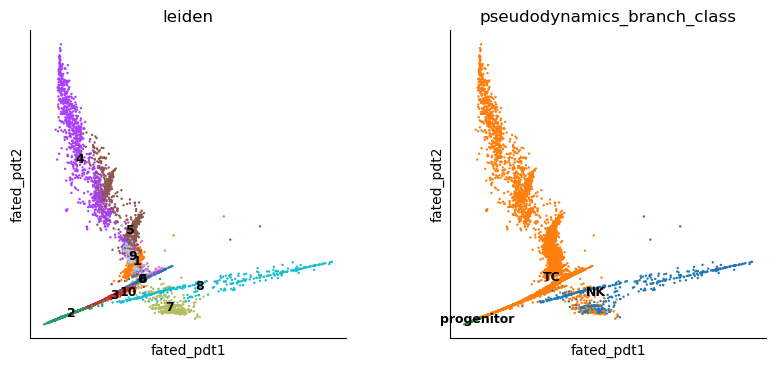

In [231]:
meahr.obsm['fated_pdt'] = np.multiply(meahr.obsm['palantir_fate_probabilities'].values , meahr.obs['pseudotime'].values.reshape(-1,1))
sc.pl.embedding(meahr, basis='fated_pdt', color=['leiden','pseudodynamics_branch_class'], legend_loc='on data', legend_fontsize=9)

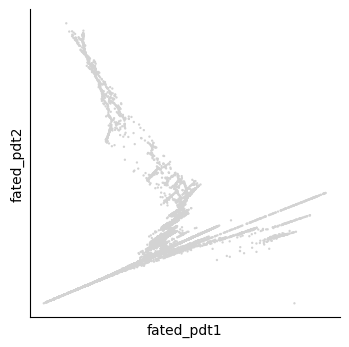

In [113]:
meahr.obsm['fated_pdt'] = np.multiply(meahr.obsm['palantir_fate_probabilities'].values , meahr.obs['palantir_pseudotime'].values.reshape(-1,1))
sc.pl.embedding(meahr, basis='fated_pdt')

# fate related genes

In [221]:
from scipy.stats import pearsonr
from tqdm.auto import tqdm

In [218]:
gene_trends = palantir.presults.compute_gene_trends(
    meahr,
    expression_key="MAGIC_imputed_data",
)

NK
[2024-09-20 22:01:14,183] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (2,931) and rank = 1.0.
[2024-09-20 22:01:14,184] [INFO    ] Using covariance function Matern52(ls=1.0).
TC
[2024-09-20 22:01:16,353] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (8,193) and rank = 1.0.
[2024-09-20 22:01:16,354] [INFO    ] Using covariance function Matern52(ls=1.0).


In [222]:
TC_ad = meahr[meahr.obsm['branch_masks']['TC']]
pseudotime = TC_ad.obs.palantir_pseudotime.values.reshape(-1,1)
expression = TC_ad.layers['MAGIC_imputed_data']

TC_R = []
i = 0
for i in range(TC_ad.shape[1]):
    TC_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
TC_R = np.array(TC_R)
TC_R = np.where(np.isnan((TC_R)), 0, TC_R)
meahr.var['TC_MAGIC_pdt_r'] = TC_R

In [227]:
TC_top_genes = meahr.var[[ 'TC_MAGIC_pdt_r']].sort_values('TC_MAGIC_pdt_r', ascending=False)
TC_genes = TC_top_genes.iloc[:10].index
TC_top_genes.head()

,TC_MAGIC_pdt_r
Gene,
Cbl,0.975359
Dgke,0.972857
Lig4,0.970196
Gm6961,0.967938
Tmem120b,0.967766


(<Figure size 1200x400 with 2 Axes>,
 <Axes: xlabel='Pseudotime', ylabel='Gm6961 trend'>)

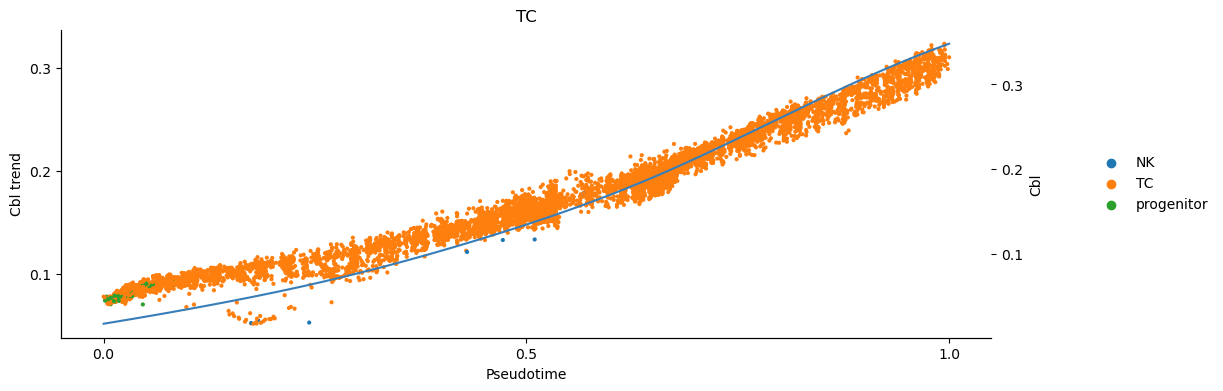

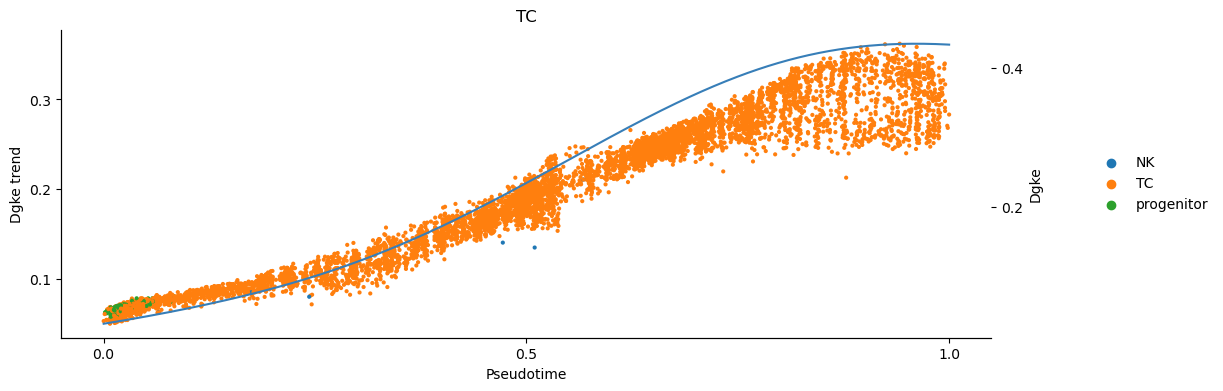

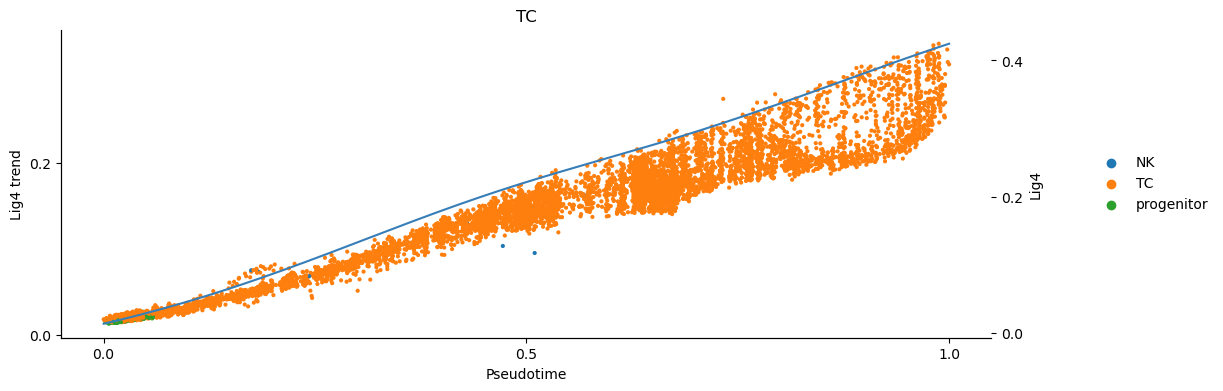

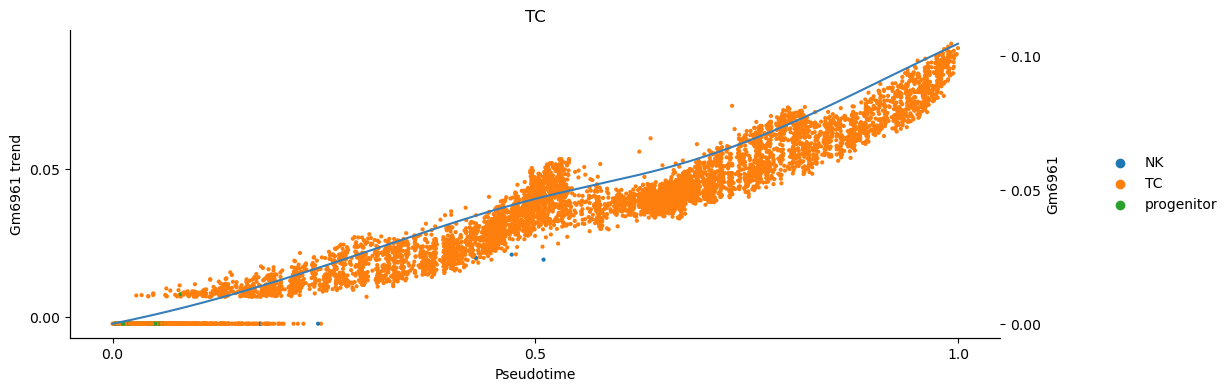

In [232]:
palantir.plot.plot_trend(meahr, "TC", "Cbl", color='pseudodynamics_branch_class', position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(meahr, "TC", "Dgke", color='pseudodynamics_branch_class', position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(meahr, "TC", "Lig4", color='pseudodynamics_branch_class', position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(meahr, "TC", "Gm6961", color='pseudodynamics_branch_class', position_layer="MAGIC_imputed_data")

## NK

In [233]:
NK_ad = meahr[meahr.obsm['branch_masks']['NK']]
pseudotime = NK_ad.obs.palantir_pseudotime.values.reshape(-1,1)
expression = NK_ad.layers['MAGIC_imputed_data']

NK_R = []
i = 0
for i in range(NK_ad.shape[1]):
    NK_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
NK_R = np.array(NK_R)
NK_R = np.where(np.isnan((NK_R)), 0, NK_R)
meahr.var['NK_MAGIC_pdt_r'] = NK_R

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [234]:
NK_top_genes = meahr.var[[ 'NK_MAGIC_pdt_r']].sort_values('NK_MAGIC_pdt_r', ascending=False)
NK_genes = NK_top_genes.iloc[:10].index
NK_top_genes.head()

,NK_MAGIC_pdt_r
Gene,
Lpxn,0.970257
Adam19,0.961651
Mllt3,0.961224
Fam78a,0.949620
Grap2,0.943673


In [241]:
NK_top_genes.head(10).index

Index(['Lpxn', 'Adam19', 'Mllt3', 'Fam78a', 'Grap2', 'Clec2i', 'Zc3hav1',
       'Hivep2', 'Rps6ka3', 'Flot2'],
      dtype='object', name='Gene')

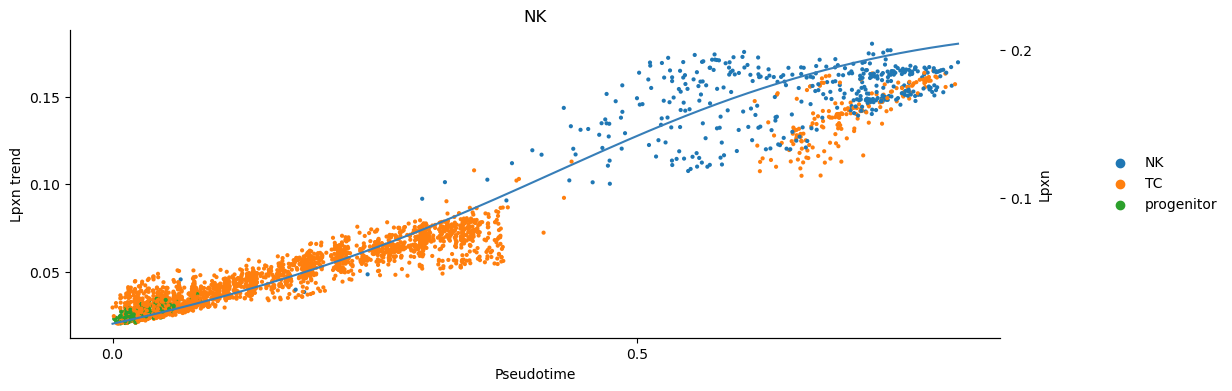

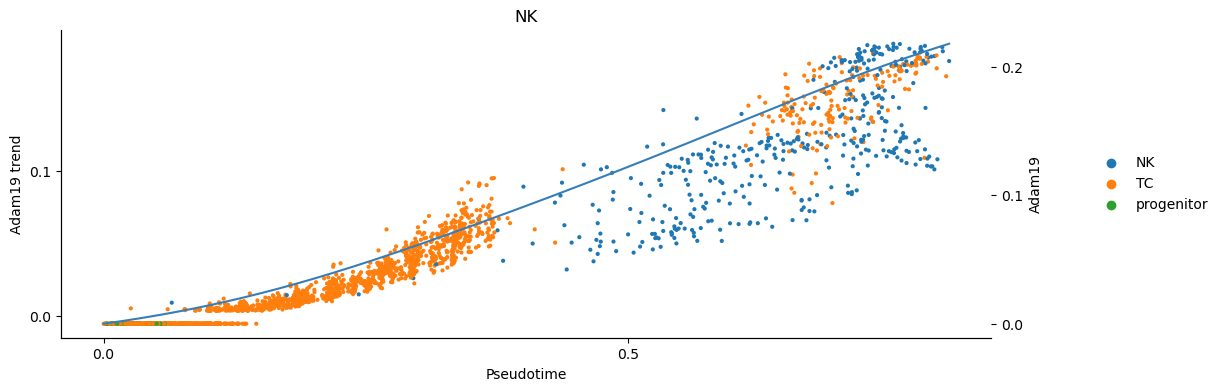

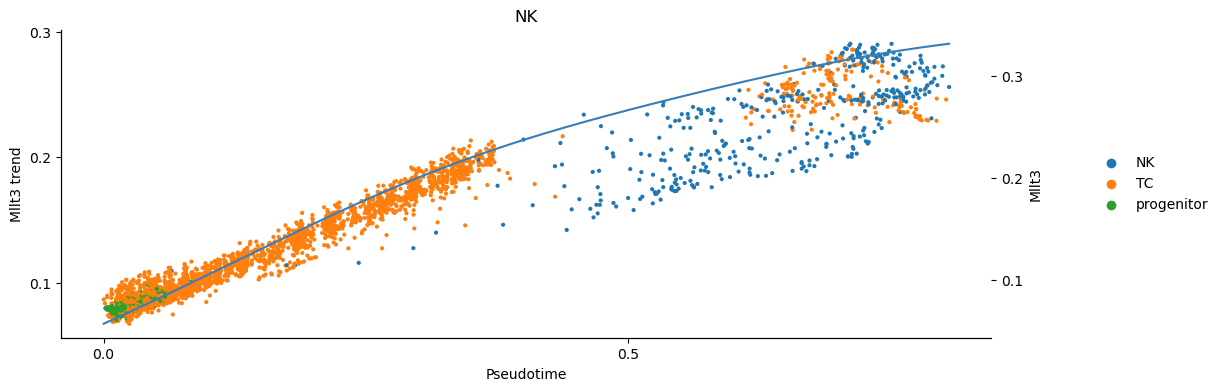

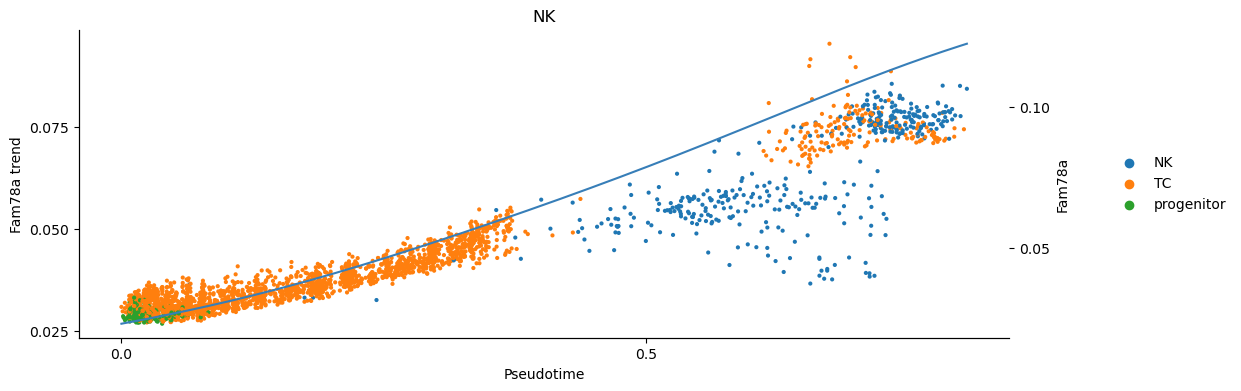

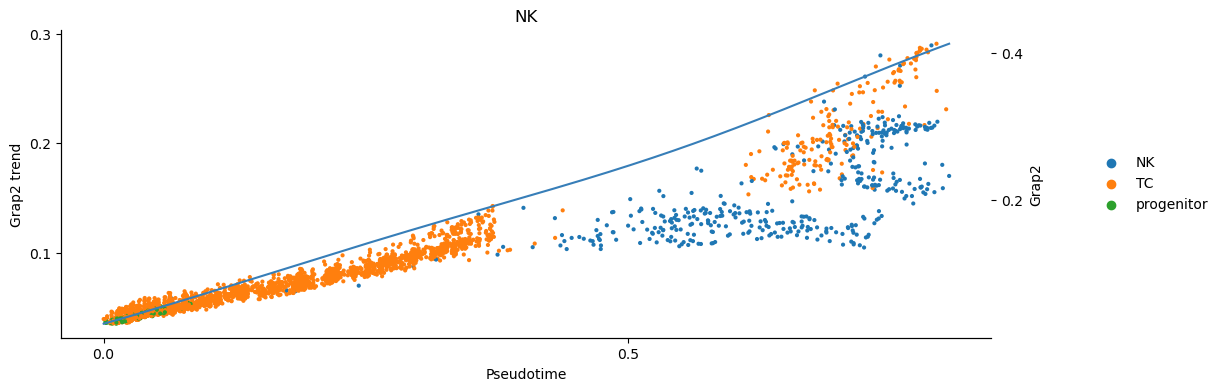

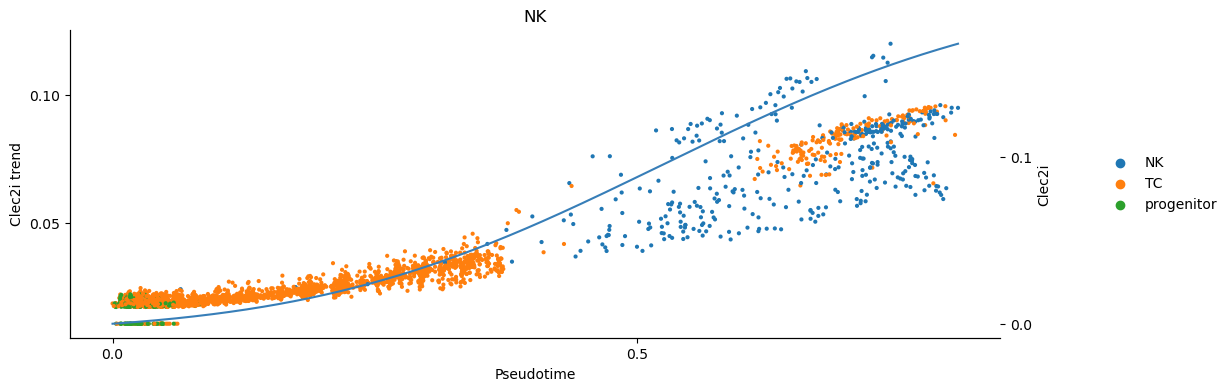

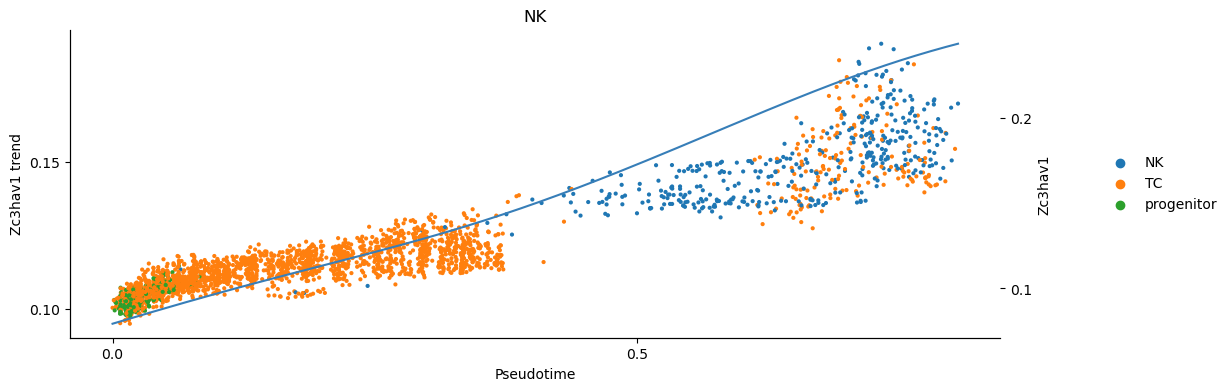

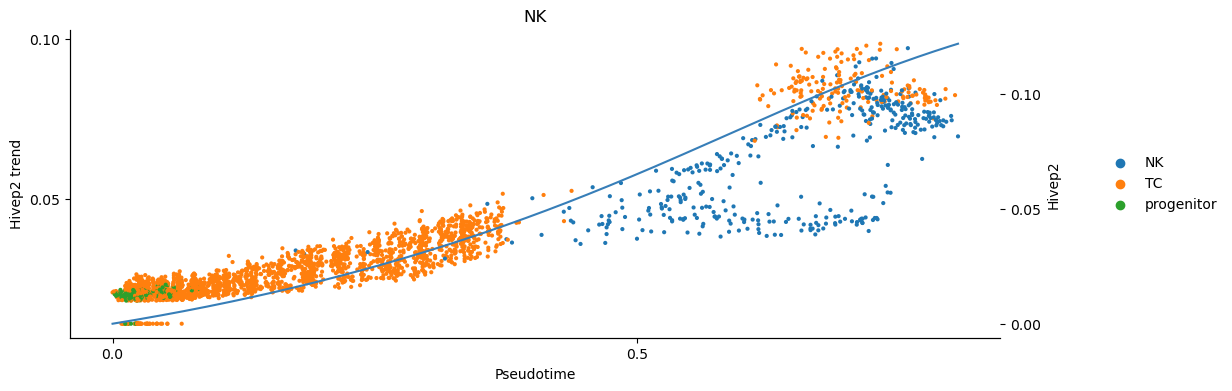

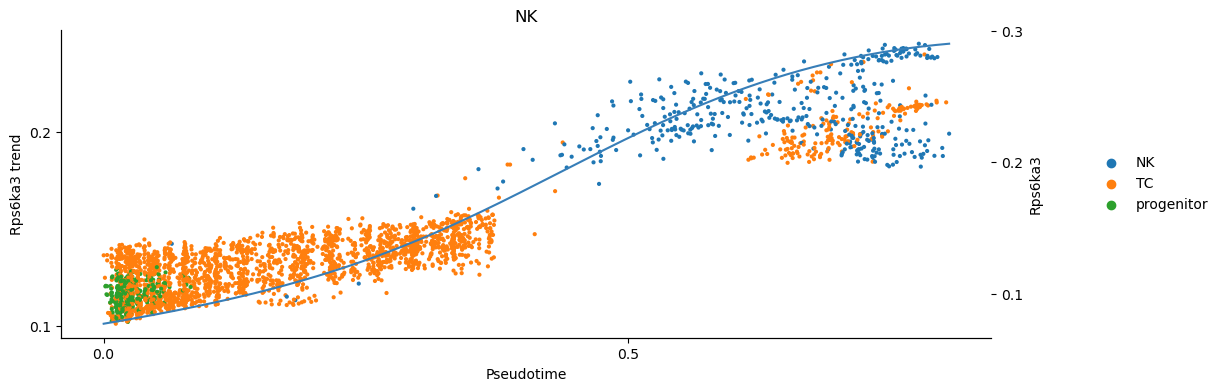

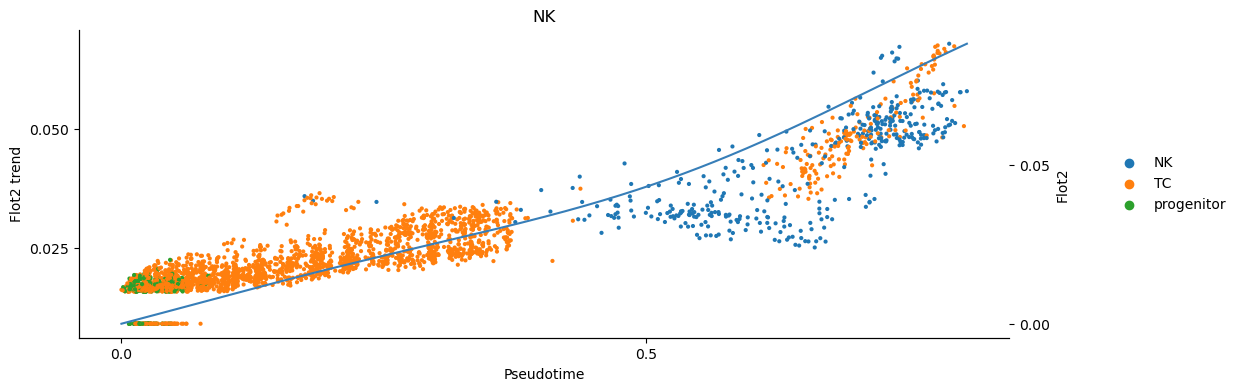

In [243]:
with plt.rc_context({"figure.figsize":(4,2), "figure.dpi":100}):
    for g in NK_top_genes.head(10).index:
        palantir.plot.plot_trend(meahr, "NK", g, color='pseudodynamics_branch_class', position_layer="MAGIC_imputed_data")

## Cell states

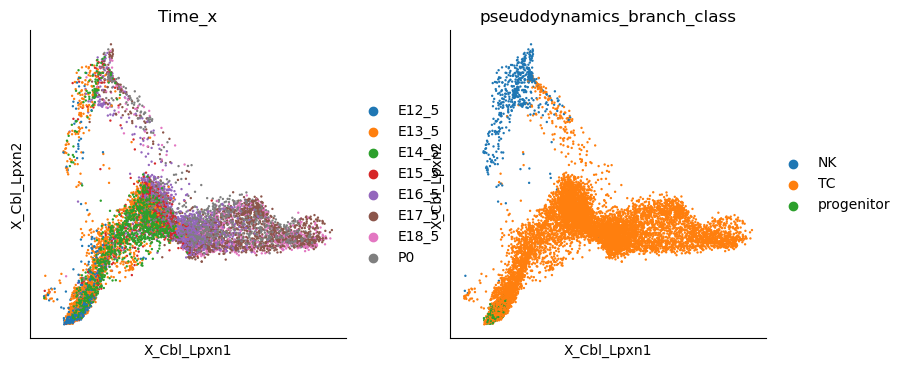

In [236]:
S = meahr[:,['Cbl', 'Lpxn']].layers['MAGIC_imputed_data']
meahr.obsm['X_Cbl_Lpxn'] = S.copy()
sc.pl.embedding(meahr, basis='X_Cbl_Lpxn', color=['Time_x', 'pseudodynamics_branch_class'])

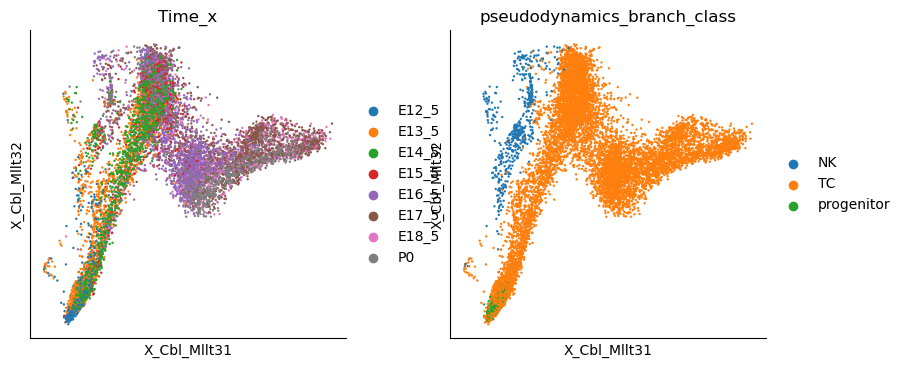

In [237]:
S = meahr[:,['Cbl', 'Mllt3']].layers['MAGIC_imputed_data']
meahr.obsm['X_Cbl_Mllt3'] = S.copy()
sc.pl.embedding(meahr, basis='X_Cbl_Mllt3', color=['Time_x', 'pseudodynamics_branch_class'])

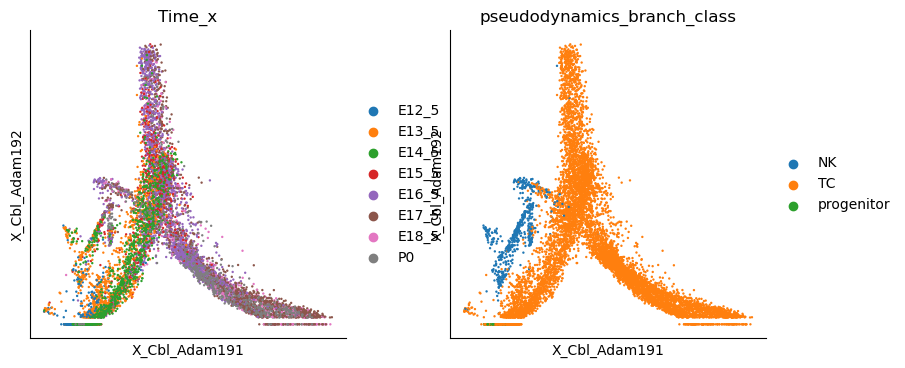

In [238]:
S = meahr[:,['Cbl', 'Adam19']].layers['MAGIC_imputed_data']
meahr.obsm['X_Cbl_Adam19'] = S.copy()
sc.pl.embedding(meahr, basis='X_Cbl_Adam19', color=['Time_x', 'pseudodynamics_branch_class'])

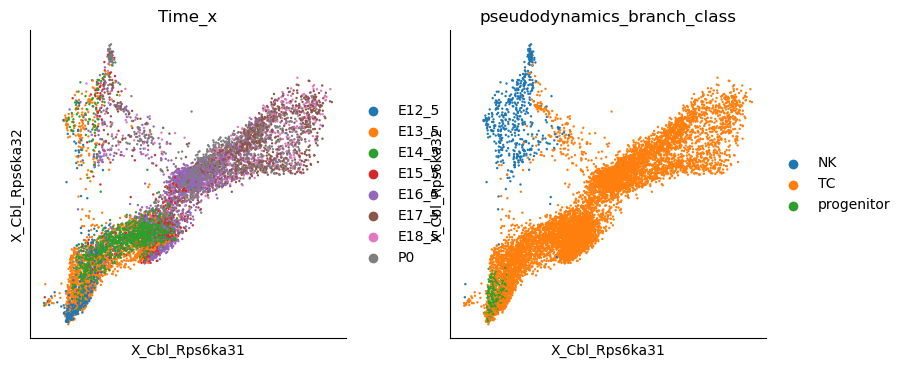

In [244]:
S = meahr[:,['Cbl', 'Rps6ka3']].layers['MAGIC_imputed_data']
meahr.obsm['X_Cbl_Rps6ka3'] = S.copy()
sc.pl.embedding(meahr, basis='X_Cbl_Rps6ka3', color=['Time_x', 'pseudodynamics_branch_class'])

In [ ]:
meahr.write_h5ad("data/David_cellstates.h5ad")

# normalize the cell states

In [5]:
meahr =  sc.read_h5ad("data/David_cellstates.h5ad")

In [9]:
X_range = meahr.obsm['X_Cbl_Lpxn'].max(axis=0) - meahr.obsm['X_Cbl_Lpxn'].min(axis=0)
X_Cbl_Lpxn_scaled = ( meahr.obsm['X_Cbl_Lpxn'] - meahr.obsm['X_Cbl_Lpxn'].min(axis=0) )/ X_range.reshape(-1,2)
meahr.obsm['Cbl_Lpxn_scaled'] = X_Cbl_Lpxn_scaled

In [ ]:
print(meahr.obsm['X_Cbl_Rps6ka3'].min(axis=0), meahr.obsm['X_Cbl_Rps6ka3'].max(axis=0))
print(meahr.obsm['Cbl_Lpxn_scaled'].min(axis=0), meahr.obsm['Cbl_Lpxn_scaled'].max(axis=0))

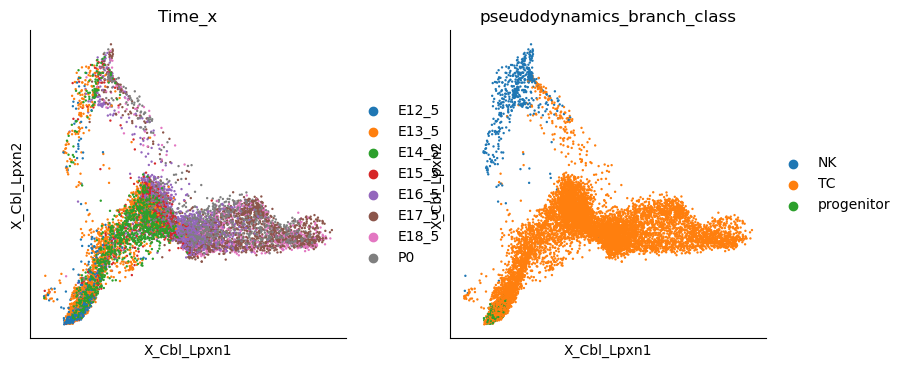

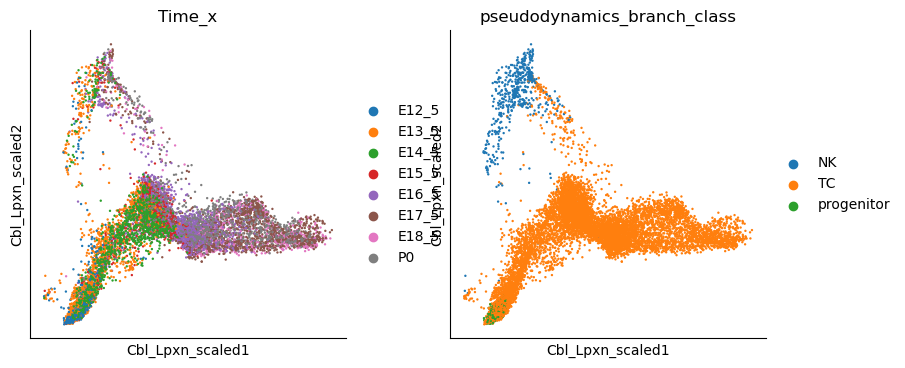

In [15]:
sc.pl.embedding(meahr, basis='Cbl_Lpxn_scaled', color=['Time_x', 'pseudodynamics_branch_class'])

## X_Cbl_Rps6ka3

In [17]:
X_range = meahr.obsm['X_Cbl_Rps6ka3'].max(axis=0) - meahr.obsm['X_Cbl_Rps6ka3'].min(axis=0)
X_Cbl_Rps6ka3_scaled = ( meahr.obsm['X_Cbl_Rps6ka3'] - meahr.obsm['X_Cbl_Rps6ka3'].min(axis=0) )/ X_range.reshape(-1,2)
meahr.obsm['Cbl_Rps6ka3_scaled'] = X_Cbl_Rps6ka3_scaled

In [18]:
print(meahr.obsm['X_Cbl_Rps6ka3'].min(axis=0), meahr.obsm['X_Cbl_Rps6ka3'].max(axis=0))
print(meahr.obsm['Cbl_Rps6ka3_scaled'].min(axis=0), meahr.obsm['Cbl_Rps6ka3_scaled'].max(axis=0))

[0.01809306 0.07700037] [0.34801397 0.29030985]
[0. 0.] [1. 1.]


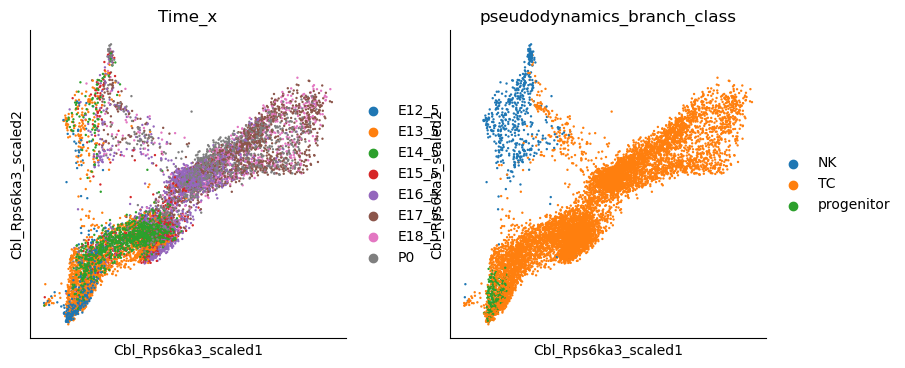

In [19]:
sc.pl.embedding(meahr, basis='Cbl_Rps6ka3_scaled', color=['Time_x', 'pseudodynamics_branch_class'])

## population size

In [20]:
popsize = pd.read_csv("data/meahr/pdny_input/pseudodynamics_input_maehr17_popsize.csv")
popsize = popsize.rename({"day":"t","CellsPerLobe":"mean", "sd":"var",  "replicates":"n_lib"}, axis=1)
pop = {key:popsize[key].values for key in popsize.columns}

In [36]:
pop['mean'] / pop['mean'][0]

array([  1.        ,   1.68862275,   5.17365269,  14.13173653,
        58.62275449, 134.43113772, 320.35928144, 935.92814371])

In [28]:
meahr

AnnData object with n_obs × n_vars = 10250 × 7006
    obs: 'barcodes', 'batch_x', 'pseudodynamics_branching_region', 'pseudodynamics_branch_class', 'dpt_adjusted_groups', 'time', 'batch_y', 'pseudotime', 'cell', 'dc1', 'dc2', 'dc3', 'dc4', 'batch_to_match', 'leiden', 'Time_x', 'Time_y', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'palantir_pseudotime', 'palantir_entropy'
    var: 'TC_MAGIC_pdt_r', 'NK_MAGIC_pdt_r'
    uns: 'DM_EigenValues', 'Time_x_colors', 'Time_y_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pseudodynamics_branch_class_colors', 'umap', 'pop'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_Cbl_Adam19', 'X_Cbl_Lpxn', 'X_Cbl_Mllt3', 'X_Cbl_Rps6ka3', 'X_dc', 'X_diffmap', 'X_pca', 'X_tsne', 'X_umap', 'branch_masks', 'diff component', 'fated_pdt', 'palantir_fate_probabilities', 'palantir_fated_pdt', 'Cbl_Lpxn_

In [37]:
meahr.write_h5ad("data/David_cellstates.h5ad")

# generate monocle-2 pse single-branch h5ad

In [4]:
meahr = sc.read_h5ad("data/David_cellstates.h5ad")

In [5]:
input = pd.read_csv("data/meahr/pseudodynamics_input_maehr17_monocle2_nobranching_TC.csv")
input['cell'] = input['cell'].apply(lambda x: x.replace(".e", ".E").replace('5whole', '5_Whole'))
input['cell']  = input['cell'].apply(lambda x : x.replace("P0_RightLobe", "P0_WholeThy_rep2"))
input['cell']  = input['cell'].apply(lambda x : x.replace("P0_LeftLobe", "P0_WholeThy_rep1"))

input['batch'] = input['batch'].apply(lambda x: x.replace("e1", "E1").replace('5whole', '5_Whole'))
input['barcodes'] = input['cell'].apply(lambda x: x.split(".")[0])
input['batch_to_match'] = input['cell'].apply(lambda x: x.split(".")[1])

In [6]:
input

,branching_region,branch_class,time,batch,pseudotime,cell,barcodes,batch_to_match
0,nonbranching,TC,12.5,E12_5_WholeThy_venus_rep3,6.313305,TCGCGGACCCAC.E12_5_WholeThy_venus_rep3,TCGCGGACCCAC,E12_5_WholeThy_venus_rep3
1,nonbranching,TC,12.5,E12_5_WholeThy_venus_rep3,7.733135,CCGATACCTGGG.E12_5_WholeThy_venus_rep3,CCGATACCTGGG,E12_5_WholeThy_venus_rep3
2,nonbranching,TC,12.5,E12_5_WholeThy_venus_rep3,6.265102,TAAAACAGACGG.E12_5_WholeThy_venus_rep3,TAAAACAGACGG,E12_5_WholeThy_venus_rep3
3,nonbranching,TC,12.5,E12_5_WholeThy_venus_rep3,6.831111,GATTAGAGCCGN.E12_5_WholeThy_venus_rep3,GATTAGAGCCGN,E12_5_WholeThy_venus_rep3
4,nonbranching,TC,12.5,E12_5_WholeThy_venus_rep3,5.076525,TTCACGCTACGA.E12_5_WholeThy_venus_rep3,TTCACGCTACGA,E12_5_WholeThy_venus_rep3
...,...,...,...,...,...,...,...,...
10700,nonbranching,TC,19.5,P0_RightLobe,9.201721,CATACGCCTAGN.P0_WholeThy_rep2,CATACGCCTAGN,P0_WholeThy_rep2
10701,nonbranching,TC,19.5,P0_RightLobe,13.435288,AGAAGAGTCGCN.P0_WholeThy_rep2,AGAAGAGTCGCN,P0_WholeThy_rep2
10702,nonbranching,TC,19.5,P0_RightLobe,28.642268,CAAACCCGTCAN.P0_WholeThy_rep2,CAAACCCGTCAN,P0_WholeThy_rep2
10703,nonbranching,TC,19.5,P0_RightLobe,6.808191,CCTTTCCGCGAC.P0_WholeThy_rep2,CCTTTCCGCGAC,P0_WholeThy_rep2


In [7]:
obs = meahr.obs[['barcodes', 'pseudodynamics_branch_class', 'palantir_pseudotime']].copy()
obs['obs_names'] = obs.index

In [8]:
merged = obs.merge(input, left_on=['barcodes'], right_on=['barcodes'], how='inner')

In [9]:
merged

,barcodes,pseudodynamics_branch_class,palantir_pseudotime,obs_names,branching_region,branch_class,time,batch,pseudotime,cell,batch_to_match
0,GGCATCGGTTAT,TC,0.799017,GGCATCGGTTAT.E17_5_WholeThy_rep2,nonbranching,TC,17.5,E17_5_WholeThy_rep2,18.113987,GGCATCGGTTAT.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2
1,TTTACTTTAGAG,TC,0.709219,TTTACTTTAGAG.E17_5_WholeThy_rep2,nonbranching,TC,17.5,E17_5_WholeThy_rep2,21.189312,TTTACTTTAGAG.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2
2,GTGCCGGGACAT,TC,0.773480,GTGCCGGGACAT.E17_5_WholeThy_rep2,nonbranching,TC,17.5,E17_5_WholeThy_rep2,17.515246,GTGCCGGGACAT.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2
3,ATTGTCTATATA,TC,0.633115,ATTGTCTATATA.E17_5_WholeThy_rep2,nonbranching,TC,17.5,E17_5_WholeThy_rep2,16.954217,ATTGTCTATATA.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2
4,ACTCAAAAATTC,TC,0.544784,ACTCAAAAATTC.E17_5_WholeThy_rep2,nonbranching,TC,17.5,E17_5_WholeThy_rep2,15.490953,ACTCAAAAATTC.E17_5_WholeThy_rep2,E17_5_WholeThy_rep2
...,...,...,...,...,...,...,...,...,...,...,...
10099,AAAGTCTGAAAT,TC,0.634118,AAAGTCTGAAAT.P0_WholeThy_rep1,nonbranching,TC,19.5,P0_LeftLobe,14.989193,AAAGTCTGAAAT.P0_WholeThy_rep1,P0_WholeThy_rep1
10100,TGGGTGATGTGT,TC,0.804473,TGGGTGATGTGT.P0_WholeThy_rep1,nonbranching,TC,19.5,P0_LeftLobe,25.706188,TGGGTGATGTGT.P0_WholeThy_rep1,P0_WholeThy_rep1
10101,CGCCTATGGGCT,TC,0.960536,CGCCTATGGGCT.P0_WholeThy_rep1,nonbranching,TC,19.5,P0_LeftLobe,28.144402,CGCCTATGGGCT.P0_WholeThy_rep1,P0_WholeThy_rep1
10102,GTCACAGCTGAN,TC,0.693217,GTCACAGCTGAN.P0_WholeThy_rep1,nonbranching,TC,19.5,P0_LeftLobe,7.900068,GTCACAGCTGAN.P0_WholeThy_rep1,P0_WholeThy_rep1


In [10]:
merged.time.unique()

array([17.5, 18.5, 15.5, 13.5, 16.5, 19.5, 14.5, 12.5])

In [11]:
meahr_monocle = meahr[merged.obs_names.values]
meahr_monocle.obs = merged.set_index('obs_names')

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [33]:
def norm_dpt(array):
	span = array.max() - array.min()

	min_ = array.min() - span * 0.1
	
	return (array - min_) / (span*1.15)

In [34]:
meahr_monocle.obsm['pseudotime_scaled'] = norm_dpt(meahr_monocle.obs['pseudotime']).values
meahr_monocle.obs['pseudotime_scaled'] = meahr_monocle.obsm['pseudotime_scaled']

In [35]:
meahr_monocle.obsm['pseudotime_scaled'] = meahr_monocle.obsm['pseudotime_scaled'].reshape(-1,1)

In [36]:
meahr_monocle.obsm['pseudotime_scaled'].min(), meahr_monocle.obsm['pseudotime_scaled'].max()

(0.08695652173913045, 0.9565217391304348)

In [37]:
meahr_monocle.shape, np.unique(meahr_monocle.obs_names).shape

((10104, 7006), (10104,))

In [38]:
meahr_monocle.obs_names_make_unique()
meahr_monocle.shape, np.unique(meahr_monocle.obs_names).shape

((10104, 7006), (10104,))

In [39]:
meahr_monocle.write_h5ad("data/meahr_monocle.h5ad")

# visualize density

In [13]:
meahr_monocle2 = sc.read_h5ad("data/meahr_monocle.h5ad")

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

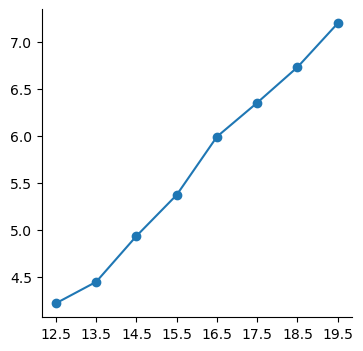

In [88]:
plt.plot(meahr_monocle2.uns['pop']['t'], np.log10(meahr_monocle2.uns['pop']['mean']), marker='o')
plt.xticks(meahr_monocle2.uns['pop']['t']);
# plt.set_xticks(meahr_monocle2.uns['pop']['t'])

<Axes: ylabel='Density'>

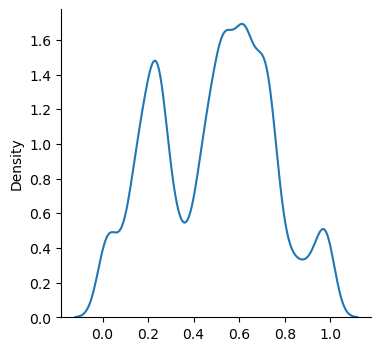

In [56]:
sns.kdeplot(meahr_monocle.obsm['pseudotime_scaled'])

<Axes: xlabel='pseudotime_scaled', ylabel='Density'>

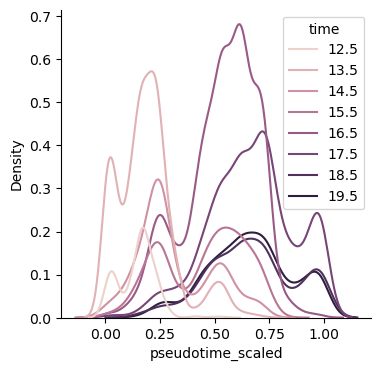

In [52]:
# sns.kdeplot(data=meahr_monocle.obs, x='pseudotime', hue='time')
sns.kdeplot(data=meahr_monocle.obs, x='pseudotime_scaled', hue='time')

<Axes: xlabel='pseudotime', ylabel='Density'>

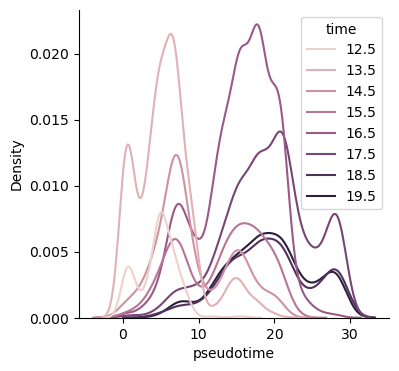

In [ ]:
sns.kdeplot(data=input, x='pseudotime', hue='time')